# Burn severity and erosion priority after the Vesuvius fire of August 2025

**The event.** A fire burned above Terzigno, on the south-east flank of Vesuvius, for four days from 8 August 2025. Copernicus EMS activation EMSR830 opened on 9 August. Press reports put the loss at about 500 hectares of pine and shrub.

**The question.** Which slopes should the park authority and the Campania civil protection treat first, before the autumn rains wash the ash off steep ground?

**The method**
1. Download Sentinel-2 images from before and after the fire.
2. Score burn severity per pixel with dNBR.
3. Add slope from the TINITALY 10 m elevation model.
4. Rank 250 m cells by severe burn on steep ground.

**The outputs**
- A ranked table of cells.
- A GeoJSON of the flagged cells.
- A plain-language summary, written by code, not by a language model. The LLM version is bonus A.

**Data.** Sentinel-2 L2A and Copernicus DEM GLO-30 from Microsoft Planetary Computer, processed locally. TINITALY 10 m elevation (INGV, CC BY 4.0) and the EFFIS burnt areas, both saved in `data/reference/`. No account or API key.

**Run.** In Colab: open the notebook from GitHub and run all cells; the first code cell fetches the repository and installs its package. Locally, with Python 3.12:

```bash
pip install -r requirements.txt -r requirements-jupyter.txt
pip install -e .
```

then run all cells. The first run downloads the pixels, a few minutes; later runs read the cache. Bonus A runs live with `pip install -r requirements-agent.txt` and a model key in `.env` (see `.env.example`); without them it replays its saved run.

In [1]:
# Setup. Outside this repository, for example in Colab, fetch it and install its package; inside it, nothing to do.
import importlib.util
import os
import subprocess
import sys
from pathlib import Path

REPO = "https://github.com/Black-Lights/vesuvius-burn-severity"
if not Path("src/burnsev").is_dir():
    if not Path("vesuvius-burn-severity").is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO], check=True)
    os.chdir("vesuvius-burn-severity")
if importlib.util.find_spec("burnsev") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", "."], check=True)
    sys.path.insert(0, str(Path("src").resolve()))  # a running kernel does not see a fresh editable install
import burnsev  # the first geospatial import; see src/burnsev/__init__.py

print("burnsev", burnsev.__version__, "ready")

burnsev 0.1.0 ready


## 1. Where, when and the rules

Every constant is set once, with its reason, in `src/burnsev/aoi.py`. Change one there and rerun.

| Setting | Value |
|---|---|
| **Box** | 14.35 to 14.50 E, 40.77 to 40.87 N: about 13 by 11 km around the cone and its south-east flank |
| **Pre-fire window** | 1 July to 7 August 2025 (scenes loaded from 1 June, to show the trend) |
| **Post-fire window** | 13 August to 15 September 2025 (scenes loaded to 15 October, to show the recovery) |
| **Severity** | dNBR in the five classes of Key and Benson (2006) |
| **Priority** | moderate or high severity (dNBR >= 0.27) on slope >= 23 degrees: the terrain term of USGS model M1 (Staley et al. 2017) |

Only the terrain term is computed. The full model also needs rainfall intensity and soil erodibility.

In [2]:
# Step 1. Every number a user might want to change lives in src/burnsev/aoi.py, with its reason next to it.
from burnsev import aoi

print("AOI (west, south, east, north):", aoi.BBOX)
print("Fire:", aoi.FIRE_START, "to", aoi.FIRE_END)
print("Pre-fire window: ", *aoi.PRE_WINDOW)
print("Post-fire window:", *aoi.POST_WINDOW)
print("Bands:", aoi.BANDS, "at", aoi.RESOLUTION, "m in", aoi.CRS)
print("Severe = dNBR >=", aoi.SEVERITY_CUT_DNBR, "->", aoi.SEVERE_CLASSES)
print("Steep  = slope >=", aoi.SLOPE_THRESHOLD_DEG, "deg; sensitivity at", aoi.SLOPE_SENSITIVITY_DEG)

# The libraries that did the geospatial work, for anyone comparing runs.
import odc.stac
import pyproj
import rasterio

print("odc-stac", odc.stac.__version__, "| rasterio", rasterio.__version__,
      "| GDAL", rasterio.__gdal_version__, "| PROJ", pyproj.proj_version_str)

AOI (west, south, east, north): (14.35, 40.77, 14.5, 40.87)
Fire: 2025-08-08 to 2025-08-12
Pre-fire window:  2025-07-01 2025-08-07
Post-fire window: 2025-08-13 2025-09-15
Bands: ['B02', 'B03', 'B04', 'B8A', 'B11', 'B12', 'SCL'] at 20 m in EPSG:32633
Severe = dNBR >= 0.27 -> ('moderate-low', 'moderate-high', 'high')
Steep  = slope >= 23.0 deg; sensitivity at (20.0, 23.0, 26.0)
odc-stac 0.5.3 | rasterio 1.5.1 | GDAL 3.12.4 | PROJ 9.8.1


## 2. Which scenes exist

A STAC search on Microsoft Planetary Computer returns the Sentinel-2 L2A products covering the box in each window, metadata only. The same search works on any STAC catalogue.

**Why Sentinel-2 L2A.** Surface reflectance, already corrected for the atmosphere, so dates compare. The two bands NBR needs, B8A in the near infrared and B12 in the short-wave infrared, at 20 m. Sentinel-2A, 2B and 2C on two orbits give 46 dates in four and a half months here, enough clear ones around a summer fire. Landsat 8 and 9 give 30 m every 8 days; HLS merges both at 30 m.

**The scene table** records date, satellite, orbit, cloud cover and processing version.

**Two choices**
- The 25 percent cloud ceiling is a coarse, tile-level filter. The real cleaning is per pixel in step 3.
- The offset is read per product, not assumed, because Sentinel-2 changed its number format in 2022.

In [3]:
# Step 2. Ask the catalogue which scenes exist over the box in each window. Metadata only, no pixels yet.
from burnsev import catalog

pre_items = catalog.search_scenes(aoi.BBOX, aoi.SERIES_START, aoi.PRE_WINDOW[1], aoi.MAX_CLOUD)
post_items = catalog.search_scenes(aoi.BBOX, aoi.POST_WINDOW[0], aoi.SERIES_END, aoi.MAX_CLOUD)
print(len(pre_items), "pre-fire and", len(post_items), "post-fire scenes under", aoi.MAX_CLOUD, "% cloud")

scenes = catalog.scene_table(pre_items + post_items)
scenes

32 pre-fire and 23 post-fire scenes under 25.0 % cloud


,id,date,satellite,orbit,tile,cloud_pct,baseline,boa_add_offset
0,S2C_MSIL2A_20250605T095051_R079_T33TVF_2025060...,2025-06-05,Sentinel-2C,79,33TVF,1.8,05.11,-1000
1,S2A_MSIL2A_20250607T095041_R079_T33TVF_2025060...,2025-06-07,Sentinel-2A,79,33TVF,0.0,05.11,-1000
2,S2A_MSIL2A_20250607T095041_R079_T33TVF_2025060...,2025-06-07,Sentinel-2A,79,33TVF,0.0,05.11,-1000
3,S2C_MSIL2A_20250608T100051_R122_T33TVF_2025060...,2025-06-08,Sentinel-2C,122,33TVF,9.5,05.11,-1000
4,S2B_MSIL2A_20250610T095029_R079_T33TVF_2025061...,2025-06-10,Sentinel-2B,79,33TVF,2.5,05.11,-1000
5,S2A_MSIL2A_20250610T100041_R122_T33TVF_2025061...,2025-06-10,Sentinel-2A,122,33TVF,2.4,05.11,-1000
6,S2B_MSIL2A_20250613T100029_R122_T33TVF_2025061...,2025-06-13,Sentinel-2B,122,33TVF,0.2,05.11,-1000
7,S2C_MSIL2A_20250615T095051_R079_T33TVF_2025061...,2025-06-15,Sentinel-2C,79,33TVF,0.6,05.11,-1000
8,S2A_MSIL2A_20250617T095051_R079_T33TVF_2025061...,2025-06-17,Sentinel-2A,79,33TVF,12.6,05.11,-1000
9,S2B_MSIL2A_20250620T095029_R079_T33TVF_2025062...,2025-06-20,Sentinel-2B,79,33TVF,1.5,05.11,-1000


**What the table shows**
- **55 products:** 32 pre-fire, 23 post-fire, all under 25 percent cloud.
- **Three satellites** (Sentinel-2A, 2B, 2C) on **two orbits** (79, 122) ten minutes apart, so some dates appear twice.
- **First post-fire scene:** 14 August, two days after containment.
- **Baseline 05.11 throughout.** Baseline 04.00 (January 2022) added 1000 to every stored value, so the offset is minus 1000, read from metadata.
- **7 June** was published twice, 90 minutes apart. Step 3 groups by solar day, so it counts once.
- **Cloud filter** on the returned metadata, in Python: this catalogue does not advertise the STAC query extension.

**Next.** Download the pixels of these 55 products, mask clouds per pixel, convert to reflectance.

## 3. Load the pixels and mask the clouds

**The cube.** odc-stac reads only the box from the band files of the 55 products, into one cube per band: shape (46, 560, 637) at 20 m in UTM zone 33.
- No reprojection: the files are already in UTM zone 33.
- The three 10 m bands are averaged to 20 m, the native size of B8A and B12.
- Same-day products are fused, first valid pixel wins.
- The download is cached. Everything after it is recomputed each run.

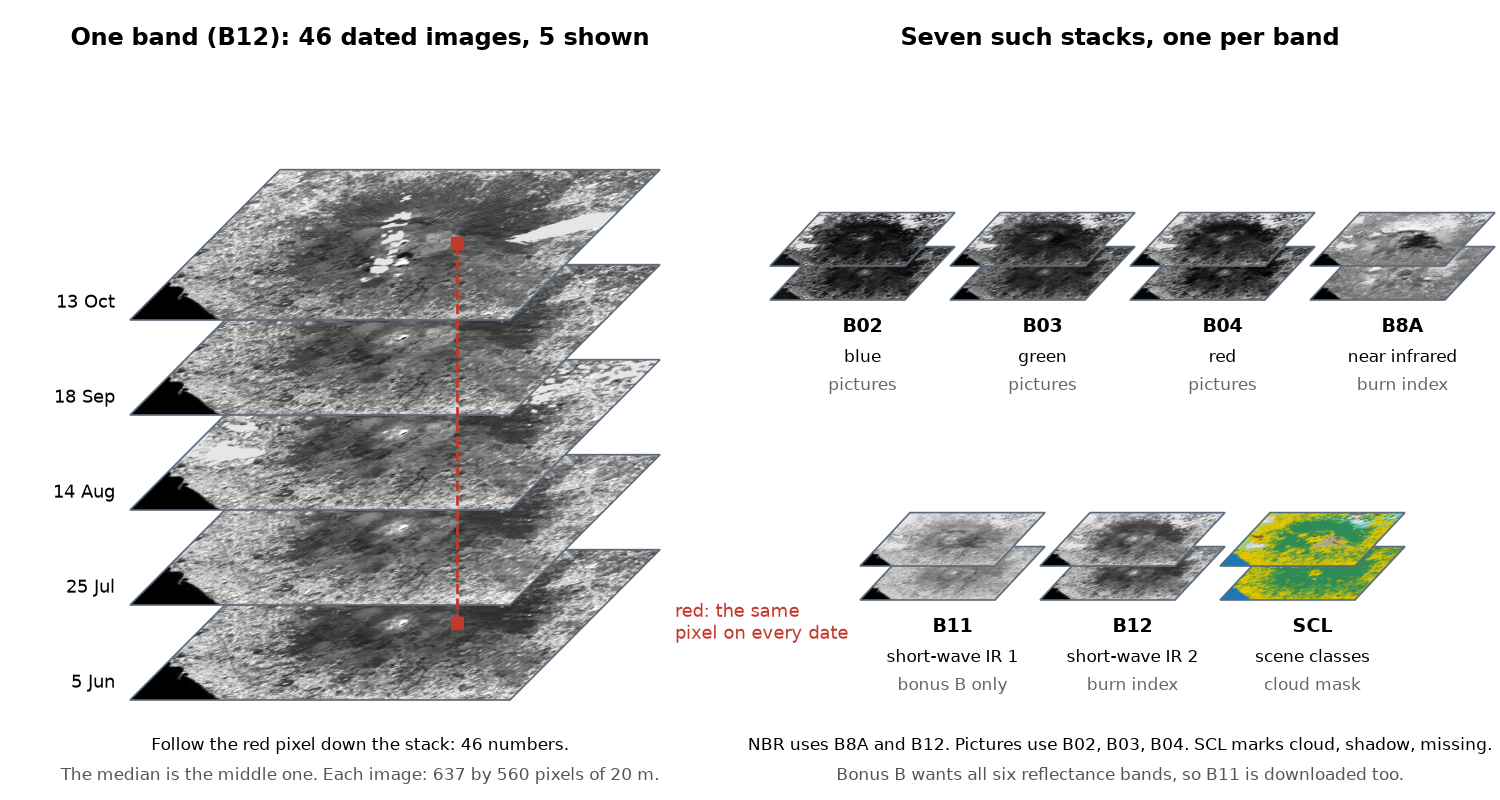

**Three steps on the raw numbers**
- **Reflectance.** (DN + BOA_ADD_OFFSET) / 10,000. The offset is minus 1,000 for all 55 products (baseline 05.11).
- **Cloud mask** from SCL: no data, saturated, cloud shadow, cloud, thin cirrus and snow are blanked. Water and dark pixels are kept: SCL is built for the atmospheric correction, [not as a land cover map](https://sentinel.esa.int/en/web/sentinel/user-guides/sentinel-2-msi/processing-levels/level-2), and on 19 August it labels a quarter of the burn as water.
- **Quality.** The usable pixel share per date is kept.

{'y': 560, 'x': 637, 'time': 46} | EPSG 32633 | reflectance cube 394 MB


<Figure size 1000x380 with 1 Axes>
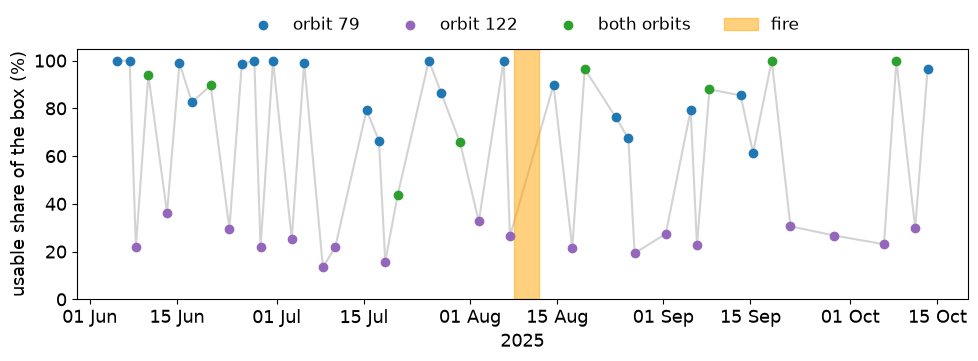

In [4]:
# Step 3. Download the pixels once (cached), then mask clouds with SCL and convert to reflectance.
from burnsev import ingest, plots

plots.fit_figures_to_width()  # every figure below scales to the width of the output area

cube_file = ingest.cache_path("s2_dn_20m")
dn = ingest.load_cached(cube_file)
if dn is None:
    dn = ingest.load_cube(pre_items + post_items)  # digital numbers, one time step per solar day
    ingest.save_cube(dn, cube_file)

refl = ingest.mask_and_scale(dn, catalog.offsets_by_day(pre_items + post_items))
print(dict(refl.sizes), "| EPSG", refl.odc.crs.epsg, "| reflectance cube", round(refl.nbytes / 1e6), "MB")
fig = plots.usable_share(refl, catalog.orbits_by_day(pre_items + post_items), (aoi.FIRE_START, aoi.FIRE_END))

**What the run shows** (the run of 23 September 2026)

*How to read the check.* "Numbers in the answer" counts every number the model wrote: dates, hectares, coordinates, percentages. "Not in the tool results" counts those the `verify` node could not find in the question, the tool arguments or the tool results. 0 means every number can be traced to a tool.

- **Tool choice.** With no dates in the question, the model called `find_fires` first, took the largest fire's dates and box from EFFIS (Terzigno, 7 to 9 August, 681 ha) and called `assess_burn` with a 1 km margin, as its docstring asks.
- **Other dates, close numbers.** EFFIS dates the fire from 7 August; this notebook uses 8 to 12 August (step 1). The windows move by a few days, so the agent finds 761 ha burned against 737 here, 180 ha severe and steep against 177, and 24 first-priority cells in both. The answer names the windows it used.
- **Memory.** The follow-up needed no tool call: at 26°, 21 of the 24 squares stay first, read from the sensitivity table returned in the first turn.
- **Two readers, one set of numbers.** Turn 3 answers the same question for a specialist, with dNBR, the windows, the usable dates per pixel and the tool's limitations; turns 1 and 3 give the same hectares and cells.
- **The brief's example.** Turn 4 compares summer 2022 with summer 2024: median NDVI 0.509 and 0.525, and 1,348 ha (9.4 %) lost at least 0.1, in scattered patches of at most 8.4 ha. The answer says where NDVI fell, and that NDVI alone cannot say why.
- **Three models.** DeepSeek V4.1 Flash, Kimi K3 and GPT-5.4 mini made the same two calls with the same arguments, so the tool gave all three the same 761 ha and 24 cells, and every number of their answers was found. They differ in time (8.2, 41.3 and 9.4 s) and in words: GPT-5.4 mini lists the five top squares, Kimi quotes the tool's limitations, DeepSeek places the block "above Terzigno and Ottaviano", which no tool reported.
- **What the check cannot see.** It knows a number is in the results, not that it belongs to the sentence. In turn 2 the answer gives 19 squares in the treat-next group at 26°: 19 is the figure at 23°, and the table returned in turn 1 gives 8 at 26°. It also cannot check words, like the place named above. Numbers written as words are read, the prompt forbids facts about the place that the tools did not return, and the tools return their own method and limitations; a check that ties each number to its field, and one on statements, are next steps.
- **Cost.** 1 to 10 s and 4,500 to 9,500 tokens a turn with DeepSeek, the pixels already cached.

**Next.** A geospatial foundation model on the same fire.

## 4. Look before and after

**Dates.** 6 August, two days before the reported start, and 14 August, two days after containment, the first fully clear date over the burn.

**Stretch.** Each band is stretched between its 2nd and 98th percentile (the QGIS default): land reflectance sits mostly between 0.02 and 0.30, so the full 0 to 1 range would look almost black.
- The bounds come from the pre-fire image and are reused on the post-fire one, so the pair stays comparable.
- Masked pixels are light grey. The stretch is display only.

**Second row.** Short-wave infrared: B12 as red, B8A as green, B04 as blue. Healthy vegetation is bright in the near infrared and dark in the short-wave infrared, so it shows green. Burned ground is the opposite and shows dark red. That is the contrast the burn index in step 5 turns into a number.

<Figure size 1000x860 with 4 Axes>
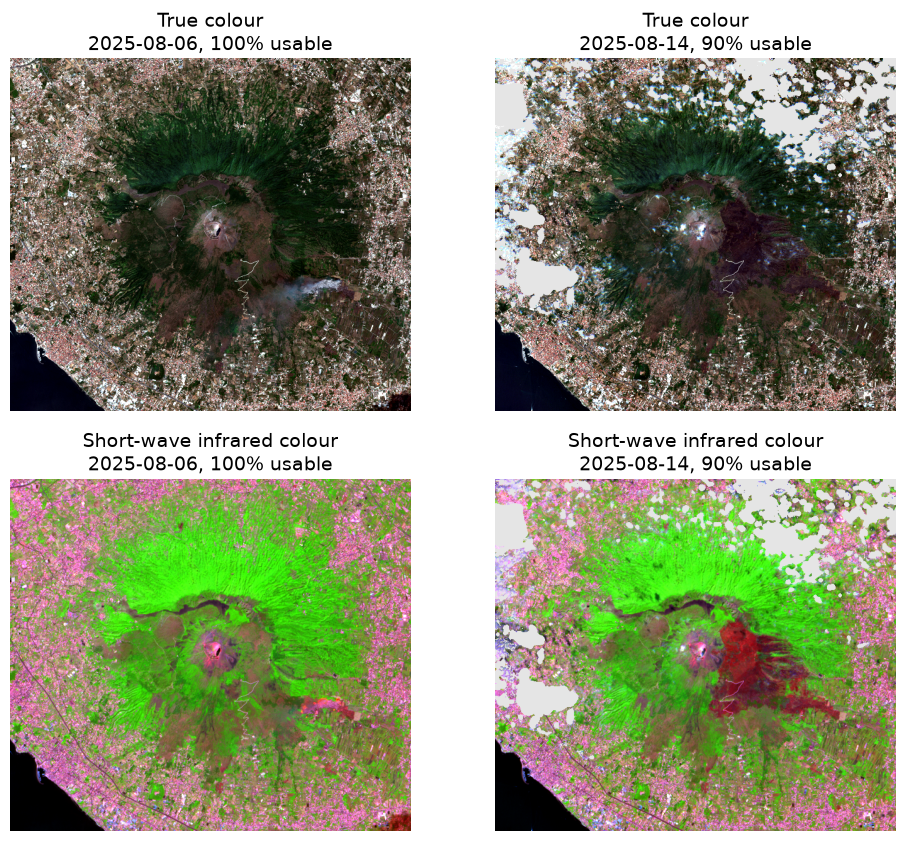

In [5]:
# Step 4. The clearest dates closest to the fire, in true colour and in short-wave infrared colour.
pre_day, post_day = "2025-08-06", "2025-08-14"
fig = plots.before_after(refl, pre_day, post_day)

**What the pictures show**
- **The burn** is a dark brown patch on the south-east flank, dark red in short-wave infrared against bright green forest.
- **6 August.** A smoke plume and a small dark red patch sit at the eastern edge of the future burn. Mean NBR inside the burn on that date is 0.39, close to the 0.43 of 25 July: the main fire came later, and one early date does not shift the pre-fire median.
- **14 August.** The clouds sit north of the cone, outside the burn, every burn pixel usable. 19 August, 24 August and 8 September are cloudier over the burn, hence this pair. 18 September is the next fully clear date.
- **Ash as water.** On 19 August the scene classification labels a quarter of the burn as water: fresh ash is as dark as water. Water stays out of the mask so a burn scar is not discarded as a lake.

**Next.** Turn the contrast into a number per pixel: NBR on each date, medians before and after, dNBR as their difference.

## 5. Composites, NBR and dNBR

**NBR** = (B8A - B12) / (B8A + B12): high for live vegetation, low for bare or charred ground. The sum cancels brightness differences between dates. Computed per pixel, per date.

**Median composites.** Each window becomes one median per pixel, not a mean: one odd date (haze, a missed cloud edge, the small fire of 6 August) cannot move it.

**Windows: 1 July to 7 August before, 13 August to 15 September after.** A median summarises a window well only when the window is stable. Before the fire, NBR inside the future burn slides through June while the unburned reference stays flat, so the pre-fire window starts in July. After the fire, recovery starts within weeks as ash washes off and grass returns, so the post-fire window is one month. That is the initial-assessment timing of Key and Benson (2006), the period Veraverbeke et al. (2010) found best for Mediterranean pine and shrub before regrowth pulls dNBR down, and the 30 days at which EFFIS computes severity. Scenes are loaded from 1 June to 15 October so the plot shows both trends.

**NDVI** = (B8A - B04) / (B8A + B04), the second index. NBR reacts to char and ash through the short-wave infrared; NDVI reacts to green leaf through the red band, the cover that holds the soil. It is plotted next to NBR, mapped before and after, and carried to the grid in step 9 as the green cover left after the fire.

**dNBR** = median before minus median after. Positive means vegetation lost; step 6 classifies it.

The cell prints the source of the index functions, so the formula on this page is the code that ran, and counts the usable observations behind each pixel.

```python
def nbr(ds: xr.Dataset) -> xr.DataArray:
    """Normalised Burn Ratio, (B8A - B12) / (B8A + B12), per pixel and date.

    Healthy vegetation is bright in the near infrared (B8A) and dark in the short-wave
    infrared (B12), so NBR is high. Burned ground is the reverse, so NBR drops after a fire.
    """
    return normalised_difference(ds["B8A"], ds["B12"]).rename("NBR")
```

```python
def ndvi(ds: xr.Dataset) -> xr.DataArray:
    """Normalised Difference Vegetation Index, (B8A - B04) / (B8A + B04), per pixel and date.

    NBR reacts to char and ash through the short-wave infrared; NDVI reacts to green leaf
    through the red band. After a fire it measures the cover left to hold the soil. B8A (the
    narrow near-infrared band) is used instead of the 10 m B08 so both indices share the 20 m grid.
    """
    return normalised_difference(ds["B8A"], ds["B04"]).rename("NDVI")
```

```python
def dnbr(nbr_da: xr.DataArray, pre: tuple[str, str], post: tuple[str, str]) -> xr.DataArray:
    """dNBR = median NBR before the fire minus median NBR after it. Positive means burned.

    Differencing removes what the two composites share (soil colour, terrain, the sensor)
    and keeps the change, which is what the severity classes are defined on.
    """
    return (window_median(nbr_da, *pre) - window_median(nbr_da, *post)).rename("dNBR")
```

pre-fire: usable observations per pixel, min 2, median 7, max 14
post-fire: usable observations per pixel, min 1, median 7, max 12


<Figure size 1000x2000 with 4 Axes>
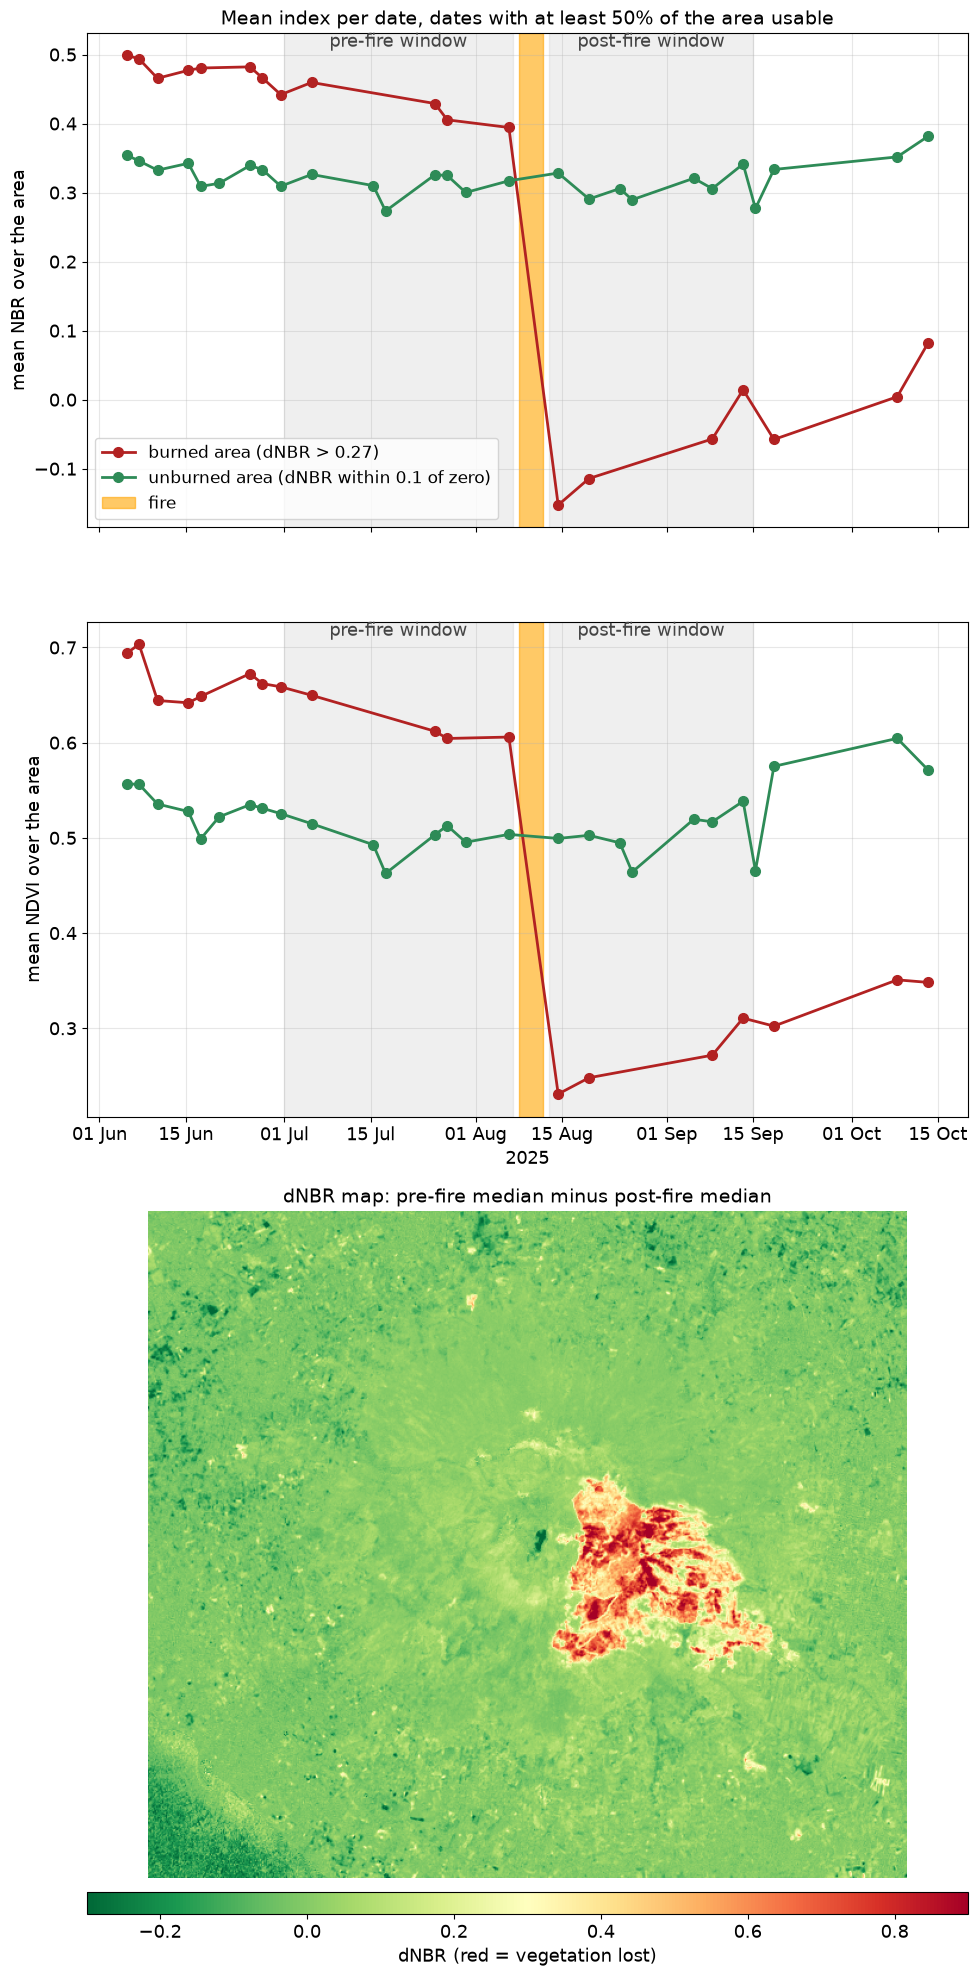

<Figure size 1000x1800 with 3 Axes>
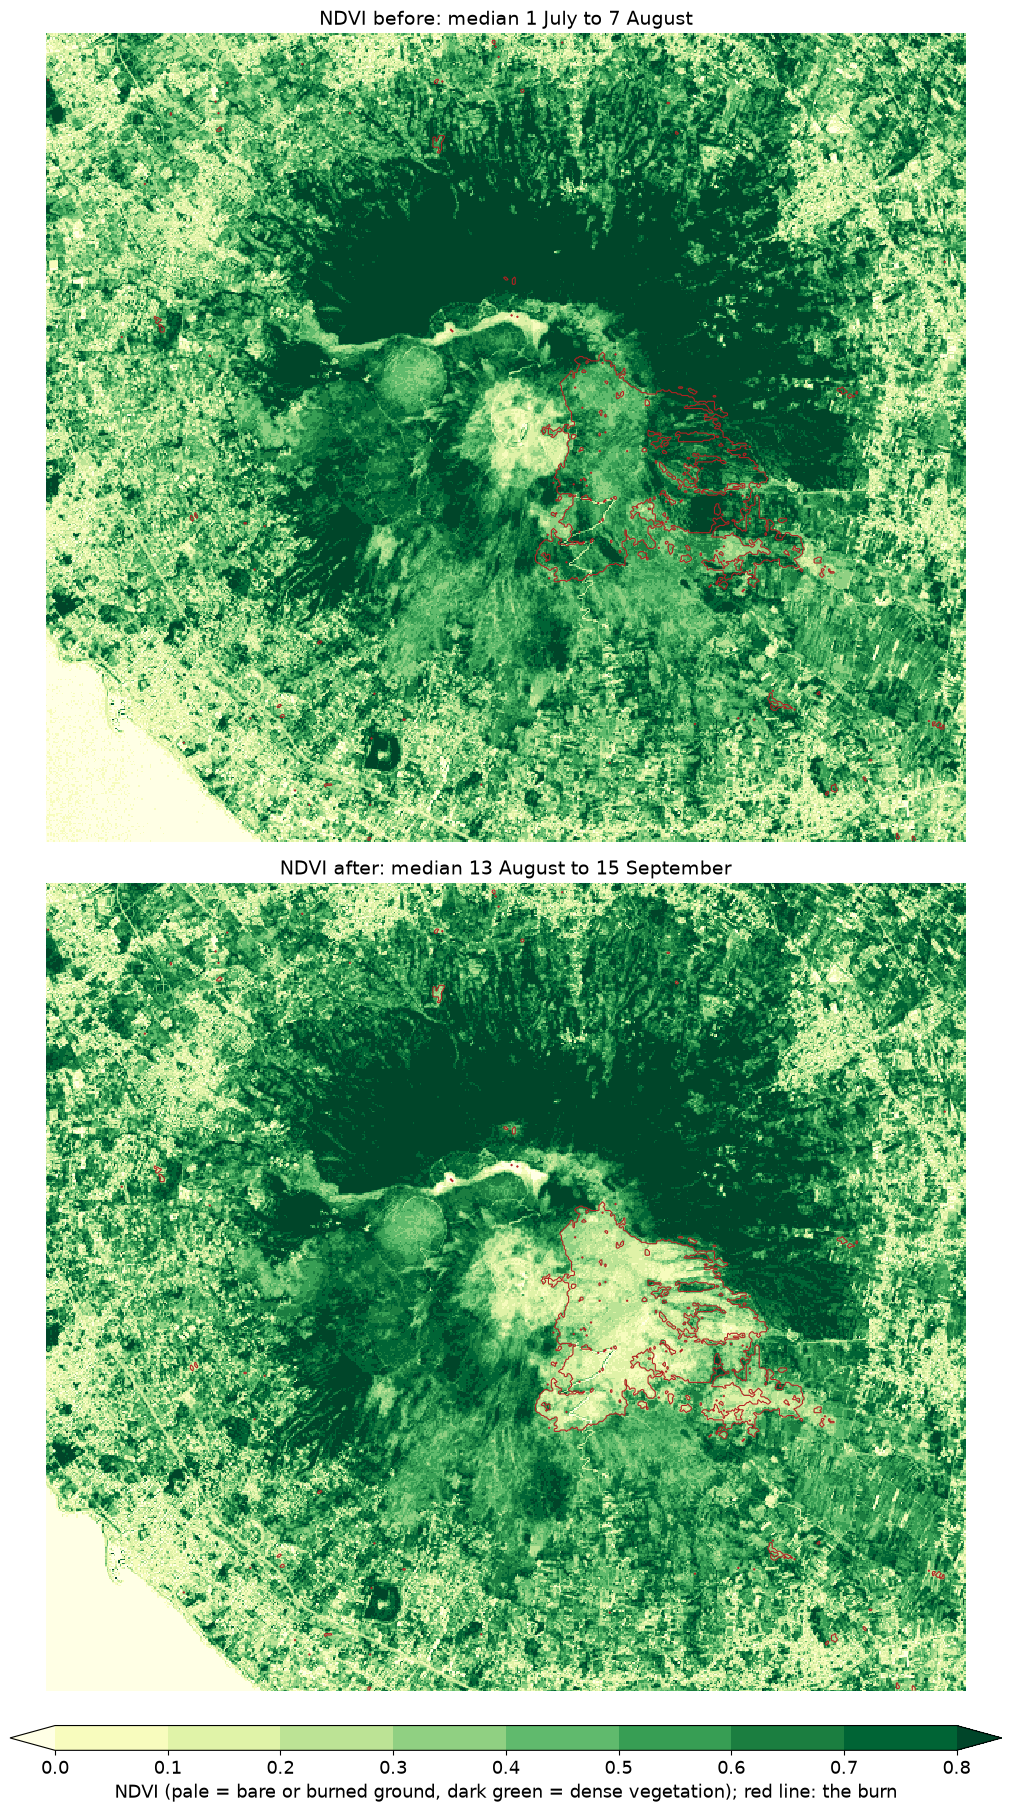

In [6]:
# Step 5. NBR and NDVI per pixel and date, the median of each window, and dNBR = before minus after.
import inspect

from IPython.display import Markdown, display

from burnsev import indices


def show(fn):
    """The source of a function, shown next to the cell that calls it."""
    return Markdown(f"```python\n{inspect.getsource(fn)}```")


display(show(indices.nbr), show(indices.ndvi), show(indices.dnbr))
nbr = indices.nbr(refl)
ndvi = indices.ndvi(refl)
dnbr = indices.dnbr(nbr, aoi.PRE_WINDOW, aoi.POST_WINDOW)
for label, window in (("pre-fire", aoi.PRE_WINDOW), ("post-fire", aoi.POST_WINDOW)):
    n = indices.window_count(nbr, *window)
    print(f"{label}: usable observations per pixel, min {int(n.min())}, median {int(n.median())}, max {int(n.max())}")

burn = dnbr > aoi.SEVERITY_CUT_DNBR
fire = (aoi.FIRE_START, aoi.FIRE_END)
fig = plots.index_history_and_dnbr(nbr, ndvi, dnbr, burn, aoi.PRE_WINDOW, aoi.POST_WINDOW, fire)
ndvi_before = indices.window_median(ndvi, *aoi.PRE_WINDOW)
ndvi_after = indices.window_median(ndvi, *aoi.POST_WINDOW)  # the green cover left, used again in step 9
fig = plots.ndvi_before_after(ndvi_before, ndvi_after, burn)

**What the run shows**
- Usable observations per pixel: pre-fire min 2, median 7; post-fire min 1, median 7.
- Inside the burn (dNBR > 0.27, 591 ha), median NBR falls from 0.44 before the fire to -0.10 after; by 13 October it is back to 0.08. The unburned area stays at 0.33 before and 0.32 after, so the drop is the fire, not the season.
- Pre-fire window: the June points sit above the July shading. NBR inside the future burn slides from 0.50 on 5 June to 0.39 on 6 August. A June start would give 637 ha of severe burn instead of 591.
- Post-fire window: recovery starts within weeks, so the window ends on 15 September. A median to 15 October would give 564 ha with a high class of 91 ha instead of 149 ha; the first clear observation per pixel gives 628 ha and 204 ha.
- dNBR inside the burn: median 0.51, 90th percentile 0.79.
- NDVI tells the same story from the red band: median 0.62 before the fire, 0.24 after inside the burn; 0.52 and 0.56 over the unburned area. By 13 October the burn is back to a mean of 0.35, about half its green cover.
- The NDVI maps show where: inside the red outline the forest turns from green to pale, while the rest of the flanks keep their colour.

**Next.** Classes and hectares per class.

## 6. Severity classes and areas

dNBR is cut into the five classes of Key and Benson (2006): unburned below 0.10, low to 0.27, moderate-low to 0.44, moderate-high to 0.66, high above. The breaks are the published ones, the same set EFFIS uses; they were calibrated in North American forests, and that is stated as a limitation rather than tuned here. A pixel exactly on a break goes to the upper class.

**One fire, one perimeter.** Outside the fire, hundreds of small patches across the box also pass the breaks: fields harvested or mown between July and September, small unrelated fires, cloud edges missed by the mask. dNBR registers the change, not its cause, and pre-fire NDVI does not separate them (they were green too). The rule is spatial: keep the largest connected patch of burned pixels, diagonals included. The pixels left out are drawn grey on the map and counted in the table, so nothing is hidden.

Area per class is the pixel count times 0.04 ha (one 20 m pixel). "Burned" means every class from low upwards; "severe" means moderate-low and above, the cut the decision rule uses.

```python
def severity_class(dnbr_da: xr.DataArray) -> xr.DataArray:
    """Class code per pixel from dNBR, using the breaks in ``aoi.SEVERITY_CLASSES``.

    0 = unburned, 1 = low, 2 = moderate-low, 3 = moderate-high, 4 = high; 255 = no data.
    A pixel exactly on a break goes to the upper class (0.27 is moderate-low).
    """
    breaks = [low for _, low, _ in aoi.SEVERITY_CLASSES[1:]]  # 0.10, 0.27, 0.44, 0.66
    codes = np.digitize(dnbr_da.values, breaks).astype("uint8")
    codes[np.isnan(dnbr_da.values)] = 255
    return dnbr_da.copy(data=codes).rename("severity")
```

```python
def main_fire(sev: xr.DataArray) -> xr.DataArray:
    """True on the largest connected patch of burned pixels (class low or above).

    Connected includes diagonal neighbours. The small patches elsewhere in the box also pass
    the dNBR breaks, but they are harvested fields, other small fires and cloud edges, not this
    fire; one fire is one perimeter.
    """
    burned = (sev.values >= 1) & (sev.values != 255)
    labels, n = ndimage.label(burned, structure=np.ones((3, 3), dtype=bool))
    if n == 0:
        return sev.copy(data=np.zeros(sev.shape, dtype=bool)).rename("main_fire")
    sizes = ndimage.sum(burned, labels, range(1, n + 1))
    return sev.copy(data=labels == int(np.argmax(sizes)) + 1).rename("main_fire")
```

whole box: burned (low and above) 955 ha, severe (moderate-low and above) 591 ha
main fire: burned (low and above) 737 ha, severe (moderate-low and above) 576 ha


,dNBR range,whole box (ha),main fire (ha)
class,,,
unburned,below 0.10,13313.3,
low,0.10 to 0.27,364.1,160.9
moderate-low,0.27 to 0.44,205.4,191.2
moderate-high,0.44 to 0.66,237.2,236.4
high,above 0.66,148.7,148.7


<Figure size 900x800 with 1 Axes>
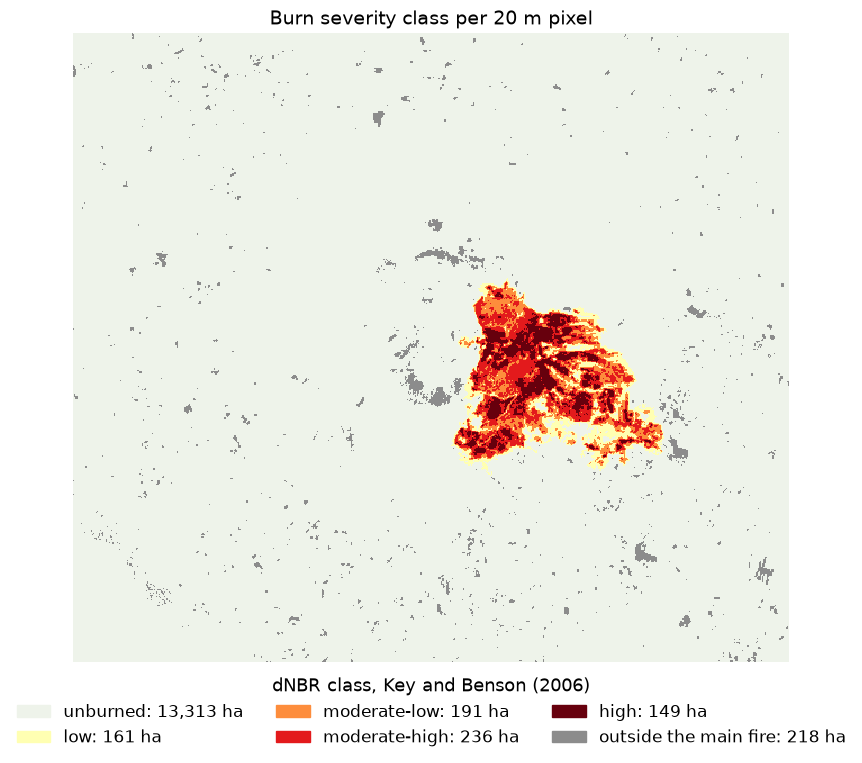

In [7]:
# Step 6. Cut dNBR into the Key and Benson classes, keep the main fire, count hectares per class.
import pandas as pd

display(show(indices.severity_class), show(indices.main_fire))
severity_all = indices.severity_class(dnbr)
fire_mask = indices.main_fire(severity_all)
severity = severity_all.where(fire_mask | (severity_all == 255), 0).astype("uint8")
outside = (severity_all >= 1) & (severity_all != 255) & ~fire_mask

names = [name for name, _, _ in aoi.SEVERITY_CLASSES]
areas_all = indices.area_by_class(severity_all, aoi.RESOLUTION)
areas = indices.area_by_class(severity, aoi.RESOLUTION)
table = pd.DataFrame(
    {"dNBR range": ["below 0.10" if lo < -1 else f"above {lo:.2f}" if hi > 1 else f"{lo:.2f} to {hi:.2f}"
                    for _, lo, hi in aoi.SEVERITY_CLASSES],
     "whole box (ha)": [areas_all.get(n, 0.0) for n in names],
     "main fire (ha)": [areas.get(n, 0.0) if n != "unburned" else "" for n in names]},
    index=names,
).rename_axis("class")
for col in ("whole box (ha)", "main fire (ha)"):
    burned = table[col].iloc[1:].astype(float).sum()
    severe = table[col].loc[list(aoi.SEVERE_CLASSES)].astype(float).sum()
    print(f"{col[:-5]}: burned (low and above) {burned:,.0f} ha, severe (moderate-low and above) {severe:,.0f} ha")
fig = plots.severity_map(severity, areas, excluded=outside)
table

**What the run shows**

| | whole box | main fire |
|---|---|---|
| burned (low and above) | 955 ha | 737 ha |
| severe (moderate-low and above) | 591 ha | 576 ha |

- **Main fire.** 737 ha in one patch on the south-east flank, 576 ha of it severe. Moderate-high and high are almost entirely inside it (236 of 237 ha, 149 of 149 ha).
- **Left out.** 218 ha in 957 patches, the largest 9.2 ha, 928 of them under 1 ha. Most of it is low class: the scattered change is mild, the fire is not.
- **NDVI agrees with the classes.** Post-fire median NDVI inside the main fire falls with severity: 0.43 in low, 0.29 in moderate-low, 0.25 in moderate-high, 0.16 in high. The classes come from the short-wave infrared, NDVI from the red band, so the order is not built in.
- **Against the press.** Around 500 ha were reported during the fire; 737 ha burned and 576 ha severe from the images. The EFFIS perimeter in step 7 is the independent check.

**Next.** Compare the main fire with the EFFIS burnt-area perimeter.

## 7. Check against the EFFIS perimeter

EFFIS, the European Forest Fire Information System of the Joint Research Centre, publishes a burnt-area polygon per fire. It maps fires from MODIS and refines the outline with Sentinel-2 at 20 m: a different team and method on the same satellite family, so agreement tests the processing, not the sensor. It is a reference, not ground truth: an extent without severity.

- **Which polygons.** Every EFFIS fire that started between the start of the pre-fire window and the start of the post-fire window, since anything burned in that span shows up as change in dNBR. Our map cannot separate fires that touch, so the comparison is against their union.
- **A fixed copy.** Fetched once from the EFFIS web feature service and saved in `data/reference/` with the fetch date. EFFIS revises its polygons and its service is sometimes down; `refresh=True` fetches again.
- **Same grid.** The polygons are reprojected to UTM 33N and rasterised on the 20 m grid, a pixel counting when its centre is inside, then compared pixel by pixel with the main fire.
- **Score.** Intersection over union (IoU): pixels burned in both maps divided by pixels burned in either. 1 means identical maps, 0 means no overlap.

```python
def rasterise(fires: list[dict], like: xr.DataArray, crs: str = "EPSG:4326") -> xr.DataArray:
    """True on every pixel of ``like``'s grid whose centre falls inside one of the polygons.

    The polygons are reprojected from ``crs`` to the grid's CRS first, so the comparison is
    pixel against pixel on the same 20 m grid.
    """
    shapes = gpd.GeoDataFrame.from_features(fires, crs=crs).to_crs(like.rio.crs).geometry
    if len(shapes) == 0:
        return like.copy(data=np.zeros(like.shape, dtype=bool)).rename("reference")
    burned = features.rasterize(
        ((geom, 1) for geom in shapes),
        out_shape=like.shape,
        transform=like.rio.transform(),
        fill=0,
        dtype="uint8",
    )
    return like.copy(data=burned.astype(bool)).rename("reference")
```

```python
def agreement(ours: xr.DataArray, ref: xr.DataArray, pixel_m: float) -> dict[str, float]:
    """Hectares burned in each map, in both, in only one, and intersection over union.

    IoU = both / (ours or reference): 1 when the two maps are identical, 0 when they do not touch.
    """
    a, b = ours.values.astype(bool), ref.values.astype(bool)
    ha = pixel_m * pixel_m / 10_000
    union = int((a | b).sum())
    return {
        "ours_ha": round(float(a.sum()) * ha, 1),
        "reference_ha": round(float(b.sum()) * ha, 1),
        "both_ha": round(float((a & b).sum()) * ha, 1),
        "only_ours_ha": round(float((a & ~b).sum()) * ha, 1),
        "only_reference_ha": round(float((~a & b).sum()) * ha, 1),
        "iou": round(float((a & b).sum()) / union, 2) if union else float("nan"),
    }
```

EFFIS polygons fetched 2026-09-23: 12 fires in the box since 2016, 3 in the windows
ours_ha: 737.1 | reference_ha: 753.2 | both_ha: 685.8 | only_ours_ha: 51.3 | only_reference_ha: 67.4 | iou: 0.85


,municipality,start,end,hectares
EFFIS id,,,,
278540,Terzigno,2025-08-07,2025-08-09,681.0
278005,Ottaviano,2025-08-09,2025-08-10,37.0
276273,Terzigno,2025-08-05,2025-08-06,36.0


<Figure size 900x800 with 1 Axes>
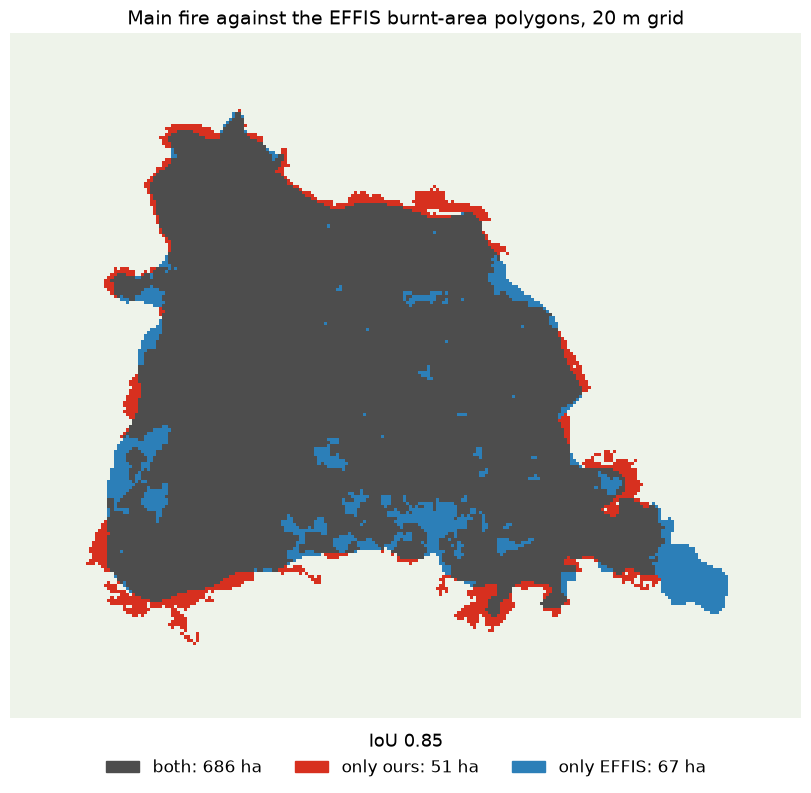

In [8]:
# Step 7. Compare the main fire with the EFFIS burnt-area polygons on the same 20 m grid.
from burnsev import reference

display(show(reference.rasterise), show(reference.agreement))
effis = reference.load_effis(aoi.BBOX)
fires = reference.fires_between(effis, aoi.PRE_WINDOW[0], aoi.POST_WINDOW[0])
effis_mask = reference.rasterise(fires, dnbr)
scores = reference.agreement(fire_mask, effis_mask, aoi.RESOLUTION)

print(f"EFFIS polygons fetched {effis['fetched']}: {len(effis['features'])} fires in the box since 2016, {len(fires)} in the windows")
print(" | ".join(f"{k}: {v}" for k, v in scores.items()))
fig = plots.agreement_map(fire_mask, effis_mask, scores)
reference.fire_table(fires)

**What the run shows**

| | hectares |
|---|---|
| EFFIS, three fires of 5 to 10 August | 753 |
| main fire, this notebook | 737 |
| burned in both | 686 |
| only in ours | 51 |
| only in EFFIS | 67 |

- **IoU 0.85.** 91 % of the EFFIS area lies in our main fire, and 93 % of our main fire lies in EFFIS.
- **Only in ours: a rim.** A median of 40 m, two pixels, outside the EFFIS edge; 41 of the 51 ha are in the low class. The edge of a burn is gradual, and the two methods draw the line in slightly different places.
- **Only in EFFIS: little change on the ground.** Median dNBR 0.06, under the 0.10 break of the low class. 16 ha are unburned islands inside our outline that the EFFIS polygon encloses. 17 ha belong to the small fire of 5 to 6 August: 7 ha that step 6 left outside the main fire, 10 ha whose change stays under the low break.
- **Fire date.** EFFIS dates the main fire from 7 August; reports give the evening of 8 August. The only image between 6 and 14 August, on 7 August, covers the west of the box and none of the fire, so no number here depends on which date is right.

**Next.** Slope from a 10 m elevation model, the terrain half of the erosion question.

## 8. Terrain: DEM and slope

**Why slope.** The erosion rule in step 9 follows the M1 model of Staley et al. (2017): the share of an area that is both burned at moderate or high severity and steeper than 23°. Sensitivity at 20° and 26°.

**Two elevation models, compared.**
- **TINITALY 1.1** (INGV, Tarquini et al. 2023): 10 m, all of Italy, built from contour lines and surveyed elevation points, so a model of the ground. Licence CC BY 4.0: the cut of the box (3.8 MB, UTM 32N) is saved in `data/reference/` with source, citation and fetch date in its tags, so the notebook does not depend on the INGV server.
- **Copernicus DEM GLO-30** from Planetary Computer: 30 m, a radar surface model with the canopy included. Computed alongside as the comparison.
- **Why TINITALY.** The USGS debris-flow models behind the 23° rule are applied with 10 m DEMs, and a 30 m source smooths short steep slopes. Open alternatives at 10 m do not exist here: Copernicus EEA-10 is restricted to eligible users, and Sentinel-1 interferometry loses coherence over vegetation.

**Slope.** The angle from the horizontal: 0° is flat ground, 90° a vertical wall; 23° rises 42 m over 100 m across, a 42 % grade. Horn's 3 by 3 method in degrees, the GDAL and QGIS default; Jones (1998) ranks it second of eight algorithms, Skidmore (1989) among the most reliable. Computed on the 10 m grid, then resampled bilinearly onto the 20 m cube grid: Grohmann (2015) shows that resampling elevation first smooths relief, so slope is derived on the finer grid.

```python
def slope_degrees(dem: xr.DataArray, pixel_m: float) -> xr.DataArray:
    """Slope in degrees with Horn's 3 by 3 method, the one GDAL and QGIS use.

    Each gradient is a weighted difference across the eight neighbours, which smooths noise
    better than a two-pixel difference. The one-pixel border has no full neighbourhood and
    is left NaN.
    """
    z = dem.values.astype("float64")
    a, b, c = z[:-2, :-2], z[:-2, 1:-1], z[:-2, 2:]  # row above
    d, f = z[1:-1, :-2], z[1:-1, 2:]  # same row, left and right
    g, h, i = z[2:, :-2], z[2:, 1:-1], z[2:, 2:]  # row below
    dz_dx = ((c + 2 * f + i) - (a + 2 * d + g)) / (8 * pixel_m)
    dz_dy = ((g + 2 * h + i) - (a + 2 * b + c)) / (8 * pixel_m)
    out = np.full(z.shape, np.nan, dtype="float32")
    out[1:-1, 1:-1] = np.degrees(np.arctan(np.hypot(dz_dx, dz_dy)))
    return dem.copy(data=out).rename("slope")
```

```python
def slope_to_grid(dem: xr.DataArray, like: xr.DataArray) -> xr.DataArray:
    """Slope computed on the DEM's own grid, then resampled onto the grid of ``like``.

    Deriving first and resampling after keeps the relief the finer grid sees; resampling the
    elevation first would smooth it (Grohmann 2015). Bilinear, because slope is continuous.
    """
    pixel_m = abs(float(dem.rio.resolution()[0]))
    slope = slope_degrees(dem, pixel_m).rio.write_crs(dem.rio.crs)
    return xr_reproject(slope, like.odc.geobox, resampling="bilinear").rename("slope")
```

TINITALY cut (1249, 1392), EPSG:32632, fetched 2026-09-23
slope in the main fire: 10th percentile 6.3°, median 16.5°, 90th percentile 30.8°


,main fire at or above (ha),severe at or above (ha),share of severe (%),"severe at or above, Copernicus 30 m (ha)"
slope threshold,,,,
20°,280.0,230.0,40.0,190.0
23°,216.0,177.0,31.0,128.0
26°,157.0,126.0,22.0,80.0


<Figure size 1000x2400 with 4 Axes>
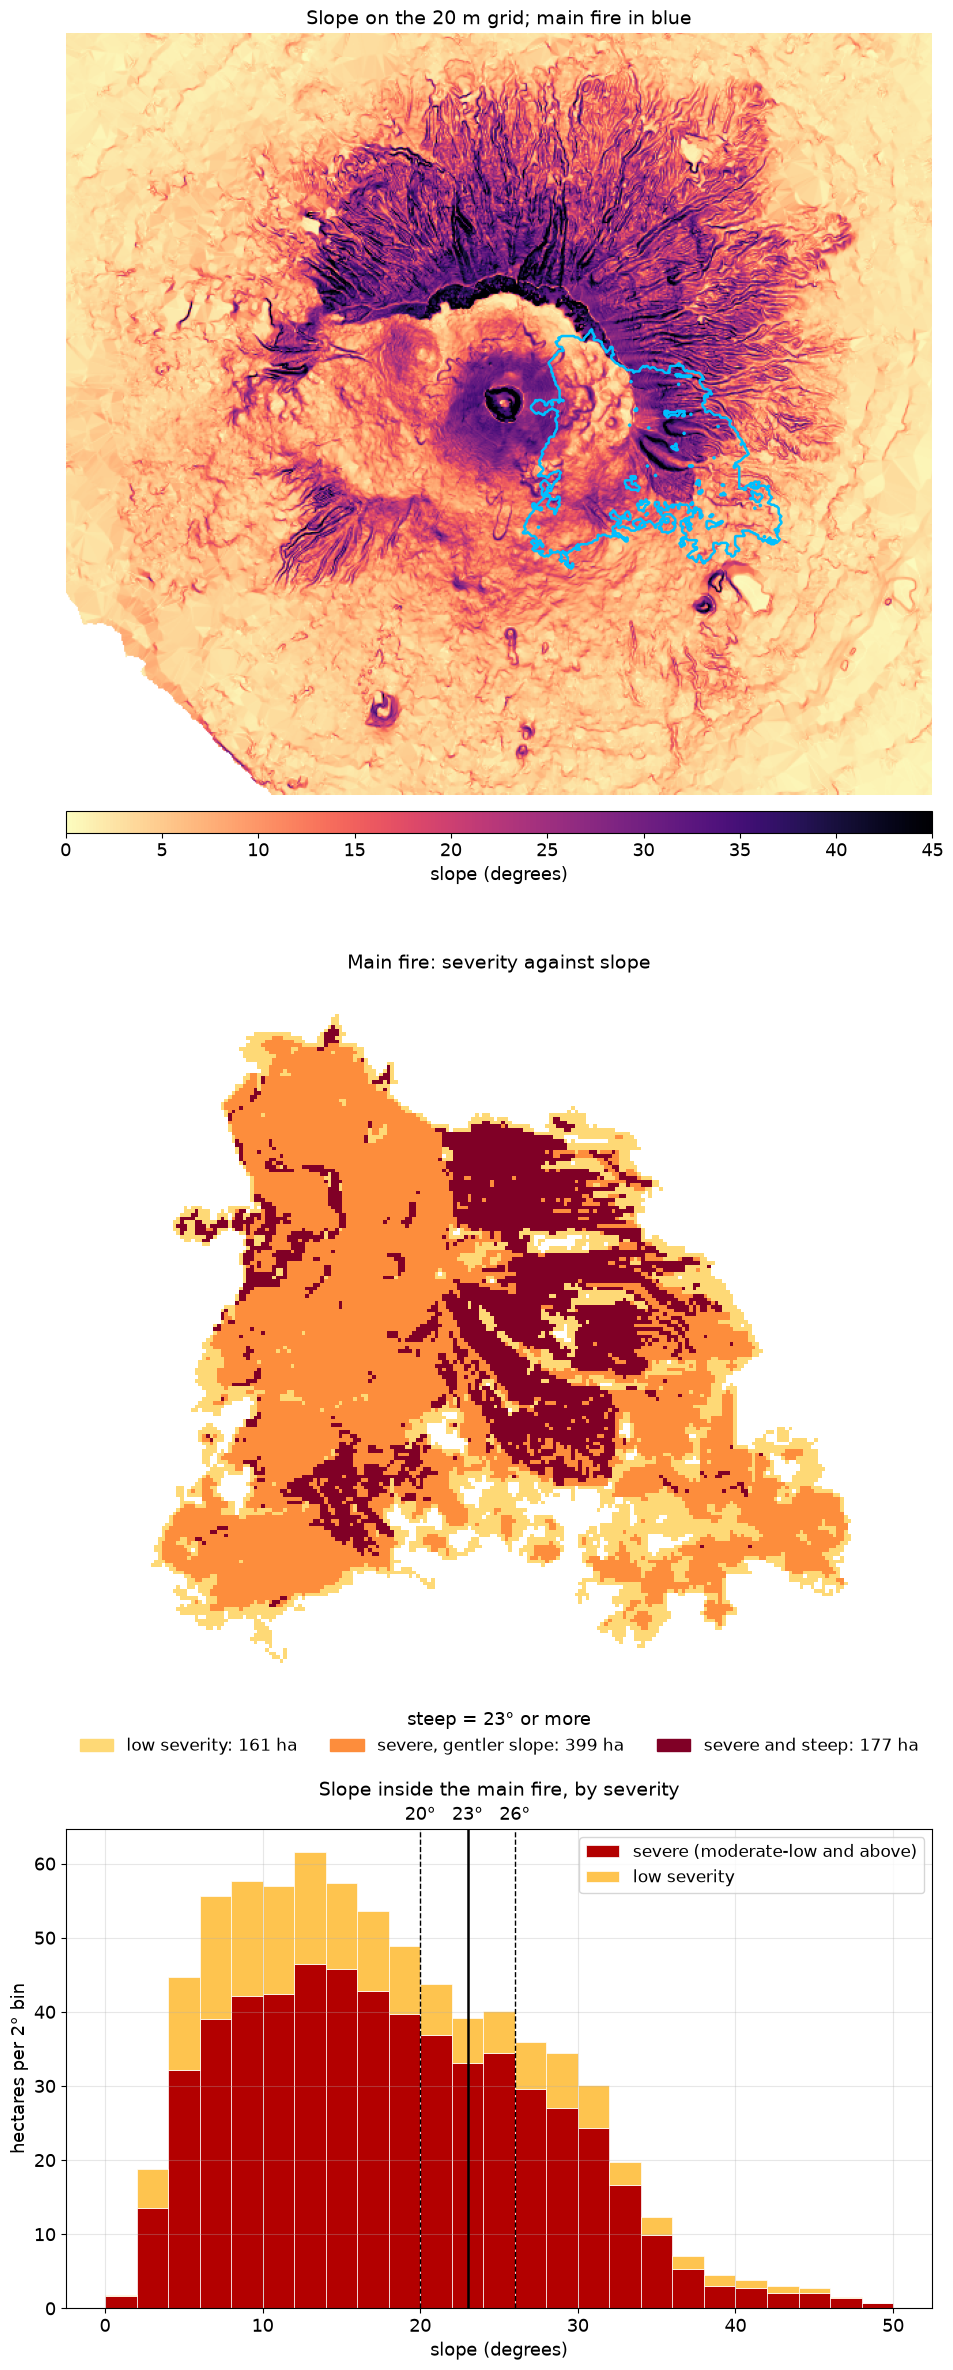

In [9]:
# Step 8. Slope from TINITALY 10 m onto the cube grid, Copernicus 30 m alongside; slopes inside the main fire.
from burnsev import terrain

display(show(terrain.slope_degrees), show(terrain.slope_to_grid))
dem = terrain.load_tinitaly(dnbr)  # 10 m, UTM 32N, the cut saved in data/reference
slope = terrain.slope_to_grid(dem, dnbr)  # Horn at 10 m, then bilinear onto the 20 m grid
slope_cop = terrain.slope_degrees(terrain.load_dem(catalog.search_dem(aoi.BBOX), dnbr), aoi.RESOLUTION)
print(f"TINITALY cut {dem.shape}, {dem.rio.crs}, fetched {dem.attrs.get('fetched')}")

severe_codes = [code for code, name in indices.class_names().items() if name in aoi.SEVERE_CLASSES]
severe = fire_mask & severity.isin(severe_codes)
ha = aoi.RESOLUTION**2 / 10_000
low, mid, high = (float(v) for v in slope.where(fire_mask).quantile([0.1, 0.5, 0.9]))
print(f"slope in the main fire: 10th percentile {low:.1f}°, median {mid:.1f}°, 90th percentile {high:.1f}°")

steep = pd.DataFrame(
    {f"{t:.0f}°": {"main fire at or above (ha)": float((fire_mask & (slope >= t)).sum()) * ha,
                   "severe at or above (ha)": float((severe & (slope >= t)).sum()) * ha,
                   "share of severe (%)": 100 * float((severe & (slope >= t)).sum()) / float(severe.sum()),
                   "severe at or above, Copernicus 30 m (ha)": float((severe & (slope_cop >= t)).sum()) * ha}
     for t in aoi.SLOPE_SENSITIVITY_DEG}
).T.round(0).rename_axis("slope threshold")
fig = plots.slope_and_fire(slope, fire_mask, severe, aoi.SLOPE_SENSITIVITY_DEG, aoi.SLOPE_THRESHOLD_DEG)
steep

**What the run shows**
- **10 m against 30 m.** Severe and steep at 23°: 177 ha with TINITALY, 128 ha with Copernicus (230 against 190 at 20°, 126 against 80 at 26°). The 10 m model keeps the gullies and short steep breaks that 30 m smooths away. Median slope in the fire 16.5°, 90th percentile 30.8°.
- **Severe and steep.** 177 of the 576 severe ha, 31 %. Each 3° step moves the area by a quarter to a third, so step 9 reports the ranking at all three thresholds.
- **Where.** Two thirds of the severe and steep ground lies in the northern half of the fire and three quarters in its eastern half: the upper eastern flank of the cone and its gullies.
- **Severity follows slope a little.** 36 % of the high class lies at 23° or more, against 24 % of the low class.
- **Limits.** TINITALY is compiled from contour lines and elevation points, so its detail is only as fine as those sources. M1 computes its share per stream catchment; step 9 uses a regular grid.

**Next.** The decision: a 250 m grid over the main fire, the share of each cell that is severe and steep, ranked.

## 9. The decision: which slopes first

**Question.** Which burned slopes should the park authority and Campania civil protection treat first against erosion and debris flows, before the autumn rains?

**Rule.** The terrain term of the M1 model of Staley et al. (2017): the share of an area that is both severe (moderate-low and above) and at least 23° steep. M1 computes it per stream catchment and turns it into a probability together with rainfall intensity. Here it is computed per 250 m grid cell, a unit a crew can be sent to, and used to rank.
- **Grid.** Cells aligned to multiples of 250 m in UTM 33N, so their edges stay fixed across runs. 250 m is not a multiple of 20 m, so a cell holds 144 to 169 pixels; the ranking uses the share, not the hectares.
- **Priorities.** At least half of the cell severe and steep: treat first. A quarter to a half: treat next. Less: monitor. The cuts are a planning choice, set in `aoi.py`.
- **Green cover.** Median post-fire NDVI over the burned pixels of each cell: the vegetation left to hold the soil. Reported, not scored.
- **Sensitivity.** The ranking again at 20° and 26°: how many first-priority cells stay first.
- **Summary.** Written by the code from the numbers, for a reader without remote sensing, so the text cannot disagree with the table.

```python
def score_cells(
    fire: xr.DataArray,
    severe: xr.DataArray,
    slope: xr.DataArray,
    green: xr.DataArray,
    threshold_deg: float,
    cell_m: float = aoi.GRID_CELL_M,
    shares: tuple[float, float] = aoi.PRIORITY_SHARES,
) -> pd.DataFrame:
    """One row per grid cell that touches the fire, ranked.

    ``severe_steep_share`` is the share of the cell's pixels that are severe and at least
    ``threshold_deg`` steep, the ranking key (a share, because cells differ in pixel count).
    ``green`` is post-fire NDVI; its median over the burned pixels of a cell says how much
    green cover is left to hold the soil. ``shares`` are the cuts between the three priorities.
    """
    rows, cols = grid_index(fire, cell_m)
    pixel_ha = float(abs(fire.x[1] - fire.x[0])) ** 2 / 10_000
    burned = fire.values.astype(bool)
    hit = burned & severe.values.astype(bool) & (slope.values >= threshold_deg)
    pixels = pd.DataFrame(
        {
            "row": rows.ravel(),
            "col": cols.ravel(),
            "burned": burned.ravel(),
            "severe": (burned & severe.values.astype(bool)).ravel(),
            "severe_steep": hit.ravel(),
            "green": np.where(burned, green.values, np.nan).ravel(),
        }
    )
    groups = pixels.groupby(["row", "col"])
    cells = pd.DataFrame(
        {
            "pixels": groups.size(),
            "burned_ha": groups["burned"].sum() * pixel_ha,
            "severe_ha": groups["severe"].sum() * pixel_ha,
            "severe_steep_ha": groups["severe_steep"].sum() * pixel_ha,
            "green_ndvi": groups["green"].median(),
        }
    )
    cells = cells[cells["burned_ha"] > 0].copy()
    cells["severe_steep_share"] = cells["severe_steep_ha"] / (cells["pixels"] * pixel_ha)
    first, second = shares
    cells["priority"] = np.select(
        [cells["severe_steep_share"] >= first, cells["severe_steep_share"] >= second],
        PRIORITY_LABELS[:2],
        PRIORITY_LABELS[2],
    )
    cells = cells.sort_values(["severe_steep_share", "severe_steep_ha"], ascending=False)
    cells.insert(0, "rank", np.arange(1, len(cells) + 1))
    cells = cells.reset_index()
    cells["x"] = (cells["col"] + 0.5) * cell_m
    cells["y"] = (cells["row"] + 0.5) * cell_m
    return cells
```

> **Summary.** The fire burned 737 ha on the south-east flank of Vesuvius. On 576 ha it burned at moderate or high severity, and 177 ha of that ground is 23° or steeper, where rain washes ash and soil downhill most easily. Treat first: 24 squares of 250 by 250 m where at least 50% of the ground is both badly burned and steep, 110 ha. 22 of them form one continuous area centred at 40.8180 N, 14.4545 E. Treat next: 16 squares at 25% to 50%, 35 ha. The first squares keep only about 49% of the green cover of unburned ground, so little holds the soil. The list hardly depends on the exact steepness limit: at 20°, 24 of the 24 stay first; at 26°, 19 do. Every square, with its coordinates, is in alert_cells.geojson and in the ranked table.

,severe and steep (ha),priority 1 cells,priority 2 cells,priority 1 cells shared with 23°
slope threshold,,,,
20°,230,31,22,24
23°,177,24,16,24
26°,126,19,10,19


,priority,severe and steep (%),severe and steep (ha),burned (ha),green cover (NDVI),lon,lat
rank,,,,,,,
1,1: treat first,99.0,6.7,6.8,0.25,14.45301,40.82410
2,1: treat first,98.0,6.1,6.2,0.13,14.45303,40.82185
3,1: treat first,97.0,6.1,6.2,0.19,14.45004,40.82409
4,1: treat first,94.0,6.4,6.8,0.21,14.45901,40.81512
5,1: treat first,91.0,5.7,6.2,0.29,14.45306,40.81735
6,1: treat first,88.0,5.0,5.7,0.11,14.45006,40.82184
7,1: treat first,83.0,4.8,5.8,0.28,14.45599,40.82186
8,1: treat first,80.0,5.4,6.8,0.16,14.45312,40.81059
9,1: treat first,79.0,5.0,6.2,0.21,14.44128,40.80828


<Figure size 1000x1050 with 1 Axes>
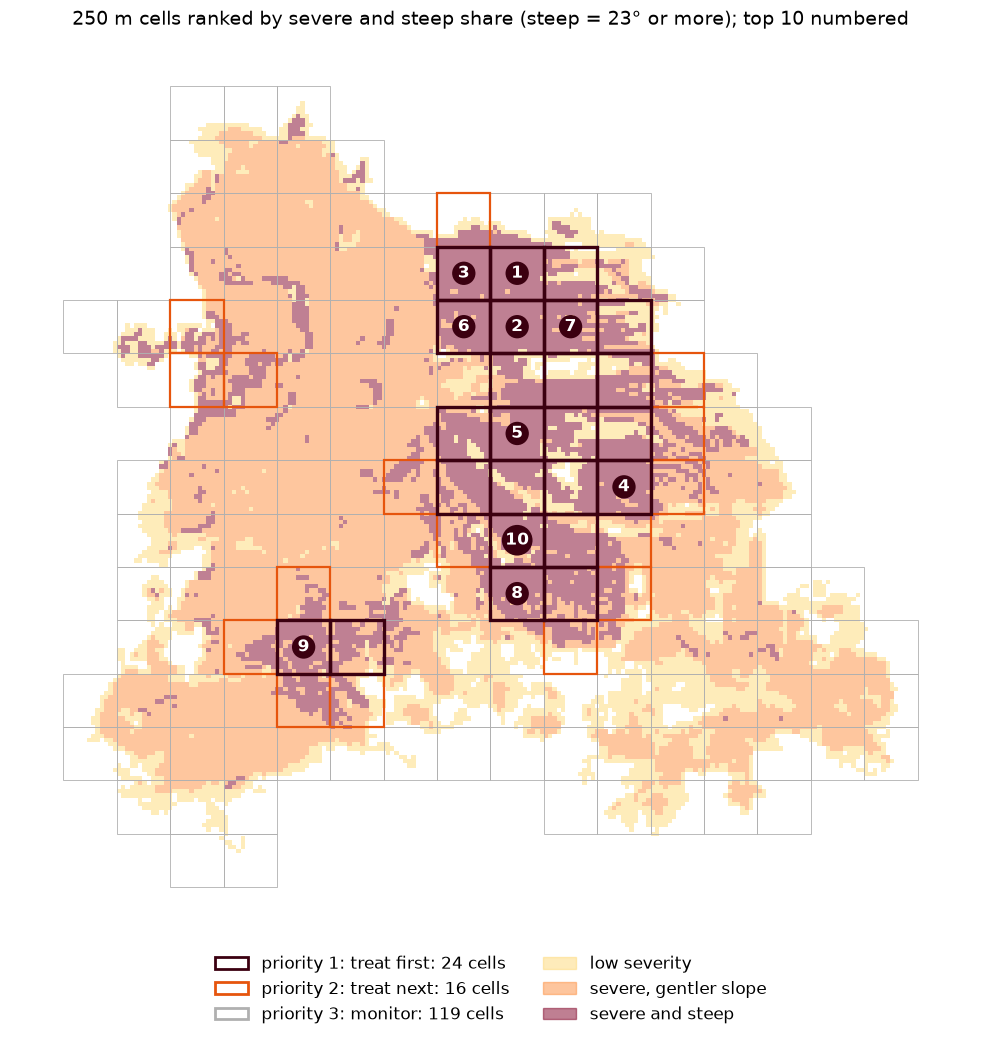

In [10]:
# Step 9. Score each 250 m cell by its severe-and-steep share, set priorities, test the slope threshold.
from burnsev import decision  # Markdown and show() come from step 5

display(show(decision.score_cells))
green = ndvi_after  # post-fire NDVI median from step 5: the green cover left
cells = decision.score_cells(fire_mask, severe, slope, green, aoi.SLOPE_THRESHOLD_DEG)
sens = decision.sensitivity(fire_mask, severe, slope, green, aoi.SLOPE_SENSITIVITY_DEG, aoi.SLOPE_THRESHOLD_DEG)
grid = decision.cells_to_geodataframe(cells, aoi.CRS)

text = decision.summary(
    grid, sens, "on the south-east flank of Vesuvius",
    burned_ha=float(fire_mask.sum()) * ha, severe_ha=float(severe.sum()) * ha,
    threshold_deg=aoi.SLOPE_THRESHOLD_DEG, green_unburned=float(green.where(abs(dnbr) < 0.1).median()),
)
display(Markdown(f"> **Summary.** {text}"), sens)
fig = plots.priority_map(cells, fire_mask, severe, slope, aoi.SLOPE_THRESHOLD_DEG, aoi.GRID_CELL_M)

ranked = grid.assign(severe_steep_pct=100 * grid["severe_steep_share"]).set_index("rank")
ranked = ranked[["priority", "severe_steep_pct", "severe_steep_ha", "burned_ha", "green_ndvi", "lon", "lat"]]
ranked.head(15).round({"severe_steep_pct": 0, "severe_steep_ha": 1, "burned_ha": 1, "green_ndvi": 2}).rename(columns={
    "severe_steep_pct": "severe and steep (%)", "severe_steep_ha": "severe and steep (ha)",
    "burned_ha": "burned (ha)", "green_ndvi": "green cover (NDVI)"})

**What the run shows**
- **The answer.** 24 cells are first priority, holding 110 ha of severe and steep ground; 16 more come next with 35 ha. Together they hold 145 of the 177 severe and steep ha, 82 %.
- **Where.** Two blocks. 22 cells form one connected block on the upper eastern flank, ranks 1 to 8 and 10 among them, 102 ha. Two cells lie apart to the south-west, ranks 9 and 24, 8 ha.
- **Robust to the threshold.** At 20° all 24 stay first priority, 31 in all. At 26°, 19 of the 24 stay. The first list does not hinge on the exact 23°.
- **Little cover left.** Median post-fire NDVI in the first-priority cells is 0.27, against 0.56 on unburned ground.
- **Not in the rule.** Rainfall, soil erodibility and what lies downslope (houses, roads) are the next layers of a real plan; section 11 lists them.

**Next.** Write the outputs: the dNBR and severity rasters as Cloud-Optimised GeoTIFF, the ranked cells as GeoJSON.

## 10. Files written

Every output goes to `outputs/` and is reopened to check it.
- **Rasters as Cloud-Optimised GeoTIFF (COG):** tiled, compressed, with overviews, so QGIS or a web map reads only the part it shows. `dnbr_20m.tif` holds dNBR as float32. `severity_20m.tif` holds the class codes of the main fire (0 unburned to 4 high, 255 no data) with the colour table built in. Both are on the 20 m analysis grid in UTM 33N (EPSG:32633).
- **Vectors as GeoJSON**, in longitude and latitude as the GeoJSON standard (RFC 7946) requires. `main_fire_perimeter.geojson` is the main fire along its pixel edges. `priority_cells.geojson` holds the 159 ranked cells with every column of the step 9 table. `alert_cells.geojson` holds only the flagged cells, priorities 1 and 2, for a field team.
- **Pictures as PNG** for reports: the before-and-after composite and the priority map.
- **Checks.** rio-cogeo validates each COG; each GeoJSON and PNG is read back.
- **Interactive map** drawn from the written files, so it also shows they open in folium. Backgrounds, one at a time: satellite, streets, the four pictures of step 4, NDVI before and after and dNBR, so one click goes from before to after and each index keeps its true colours. On top, each switched on and off: the severity classes, the severe and steep ground, the EFFIS burnt areas, the flagged cells with their numbers on hover, and the main fire outline. The rasters are reprojected to Web Mercator (EPSG:3857), the projection of web maps, taking the nearest pixel, so every colour on the map is a measured value. It runs in Jupyter, VS Code and Colab; GitHub shows the static priority map instead.

,size (KB),CRS,content,check
file,,,,
alert_cells.geojson,20,EPSG:4326,40 features,reads back
before_after.png,1553,none (picture),906 x 841 px,reads back
dnbr_20m.tif,1575,EPSG:32633,"637 x 560 px, float32",valid COG
main_fire_perimeter.geojson,43,EPSG:4326,1 features,reads back
priority_cells.geojson,78,EPSG:4326,159 features,reads back
priority_map.png,62,none (picture),981 x 1040 px,reads back
severity_20m.tif,14,EPSG:32633,"637 x 560 px, uint8",valid COG



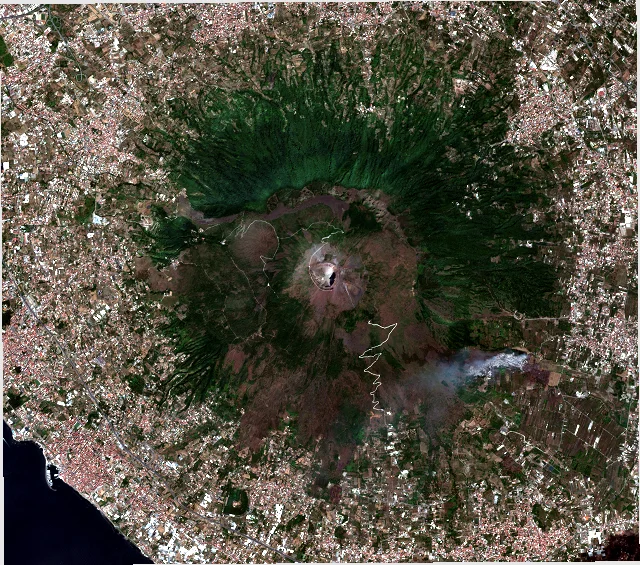
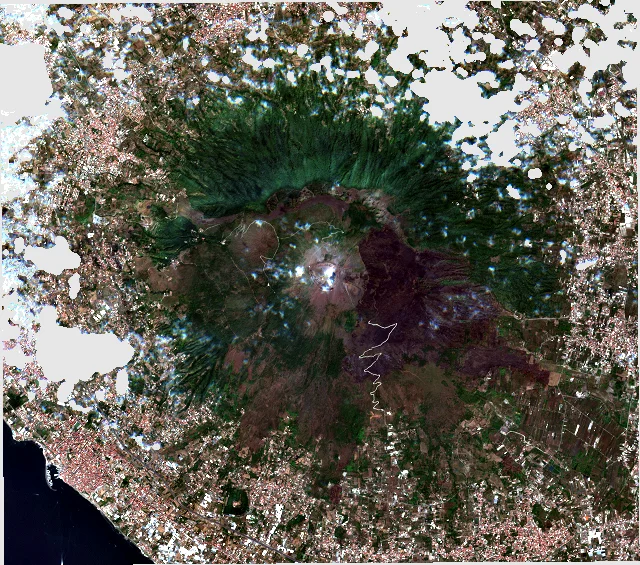
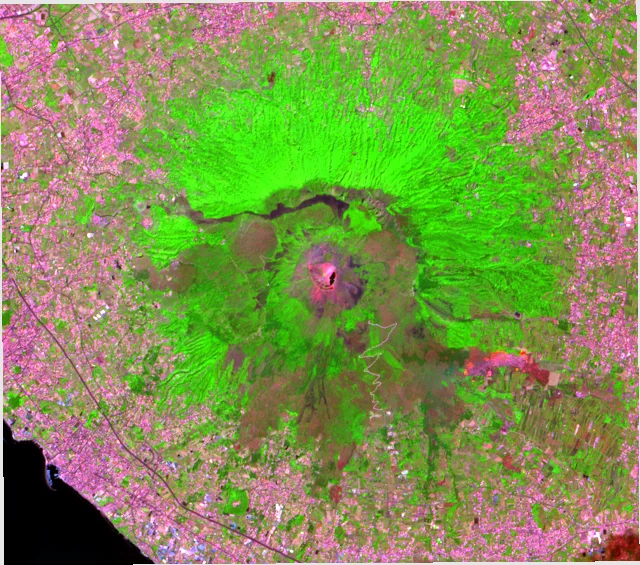
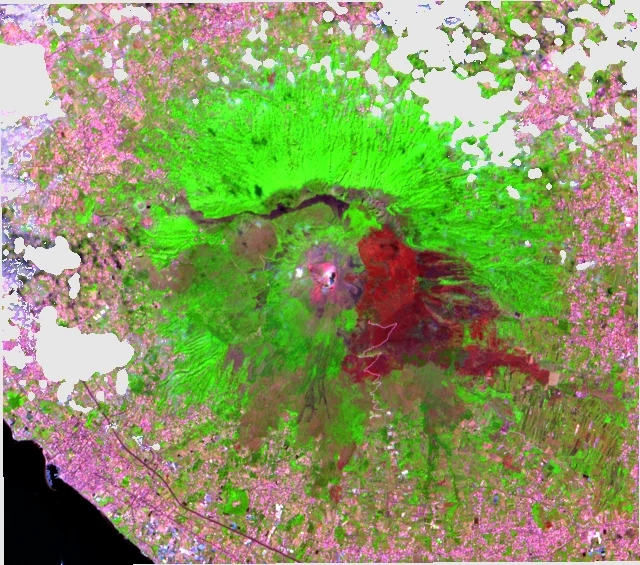
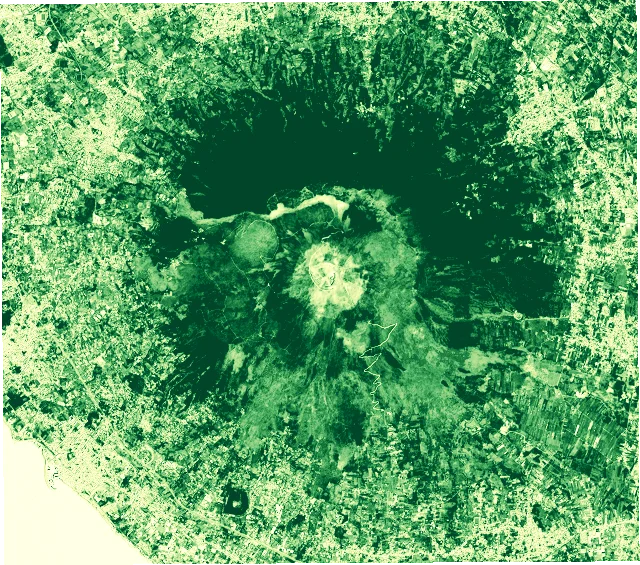
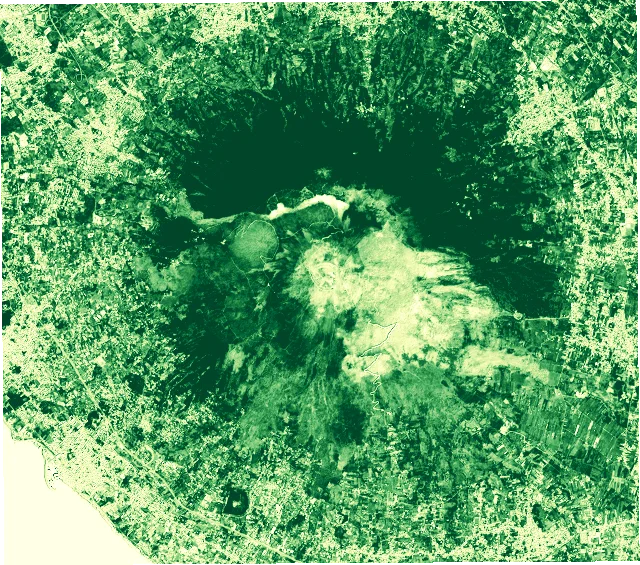
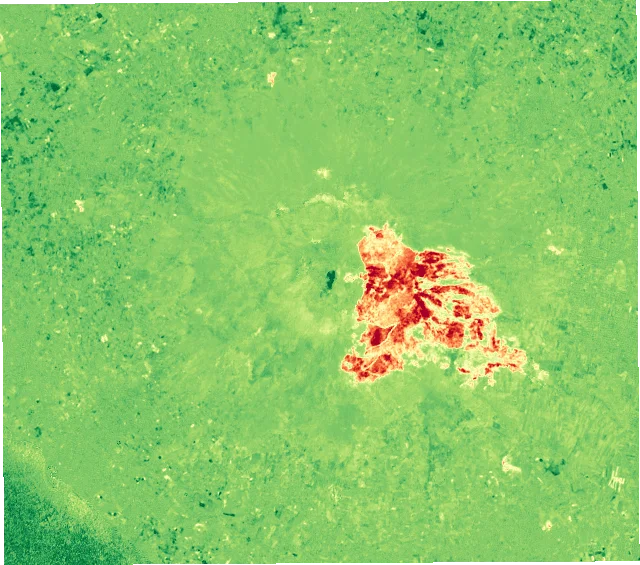
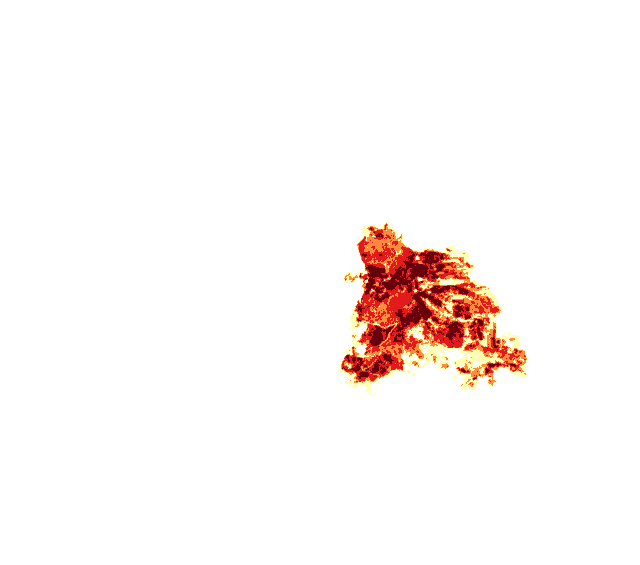
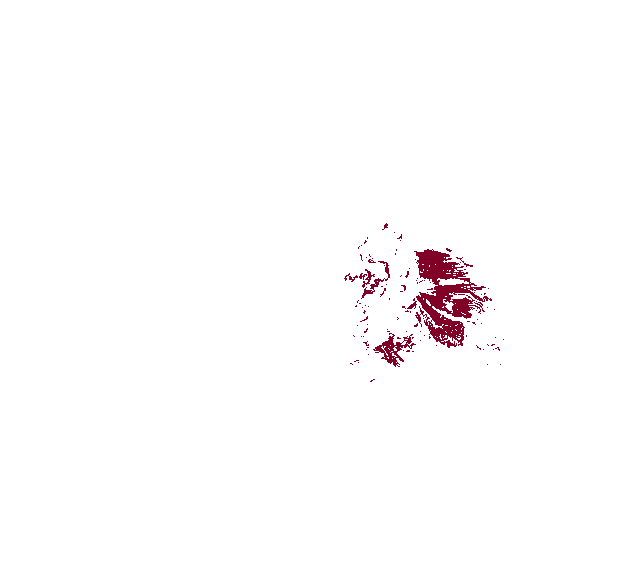

In [11]:
# Step 10. Rasters as COG, vectors as GeoJSON, two pictures as PNG; reopen and check every file; map them.
from burnsev import export

out = export.OUTPUT_DIR
source = "Sentinel-2 L2A, Microsoft Planetary Computer; vesuvius_burn_severity.ipynb"
export.write_cog(dnbr.astype("float32"), out / "dnbr_20m.tif", nodata=-9999.0, overview_resampling="average",
                 tags={"quantity": "dNBR, median NBR 1 Jul to 7 Aug 2025 minus median NBR 13 Aug to 15 Sep 2025",
                       "source": source})
export.write_cog(severity, out / "severity_20m.tif", nodata=255,
                 colormap=export.colormap_from_hex(plots.SEVERITY_COLOURS),
                 tags={"classes": "Key and Benson (2006), main fire only: 0 unburned, 1 low, 2 moderate-low, "
                                  "3 moderate-high, 4 high, 255 no data", "source": source})
export.write_geojson(export.main_fire_perimeter(fire_mask), out / "main_fire_perimeter.geojson")
cells_out = grid.round({"severe_steep_share": 3, "severe_steep_ha": 2, "severe_ha": 2, "burned_ha": 2, "green_ndvi": 3})
export.write_geojson(cells_out, out / "priority_cells.geojson")
export.write_geojson(cells_out[cells_out["priority"] != decision.PRIORITY_LABELS[2]], out / "alert_cells.geojson")
export.save_png(plots.before_after(refl, pre_day, post_day), out / "before_after.png")
export.save_png(plots.priority_map(cells, fire_mask, severe, slope, aoi.SLOPE_THRESHOLD_DEG, aoi.GRID_CELL_M),
                out / "priority_map.png")
display(export.check_outputs(out))
backgrounds = plots.picture_layers(refl, pre_day, post_day) + plots.index_layers(ndvi_before, ndvi_after, dnbr)
layers = plots.class_layers(severity, severe & (slope >= aoi.SLOPE_THRESHOLD_DEG))
plots.interactive_map(out / "main_fire_perimeter.geojson", out / "alert_cells.geojson",
                      backgrounds=backgrounds, layers=layers, effis=fires)

**What the run shows**
- **Seven files, 3.4 MB in all.** Both GeoTIFFs pass the rio-cogeo COG validation, in EPSG:32633 on the 20 m grid. The severity raster carries its colour table, and the class legend sits in its tags.
- **The perimeter** reads back as one feature of 737 ha, the main fire of step 6.
- **The ranked cells** read back as 159 features, the alert file as the 40 flagged ones. Each cell carries its rank, priority, severe-and-steep share and hectares, green cover and centre in longitude and latitude.
- **The map** above is drawn from those files, so they open in folium as written, with the pictures and the result layers of the notebook on the same map. The files also open in QGIS by drag and drop, and the GeoJSON files on geojson.io.

**Next.** What the numbers cannot say, and what comes next.

## 11. Limitations and next steps

**What the numbers cannot say**
- **An early assessment.** The post-fire window is the first month. An early map can overstate severity where scorched trees and shrubs recover, and understate it where trees die later. The extended assessment, one growing season on, is summer 2026.
- **Class breaks from elsewhere.** Key and Benson calibrated them in North American forests. No field plots exist here to recalibrate them. RdNBR (Miller and Thode 2007) would correct for sparse pre-fire cover, which matters where the 2017 fires (1,136 and 1,919 ha in EFFIS) left eight-year regrowth.
- **Canopy, not soil.** dNBR sees vegetation and surface change. M1 uses soil burn severity maps, which field teams adjust from satellite dNBR.
- **Terrain.** TINITALY is compiled from contour lines, and slope at 20 m smooths short gullies. The 30 m model gives 128 ha of severe and steep ground against 177 ha at 10 m: the DEM matters.
- **A ranking, not a probability.** M1 works per stream catchment and needs rainfall intensity and soil erodibility; here the terrain term is ranked per 250 m cell. The priority cuts are a planning choice. What lies downslope (houses, roads, channels) is not in the rule.
- **One fire.** 218 ha of scattered change outside the main fire are left out, including 7 ha of the small fire of 5 to 6 August.
- **The catalogue can change.** Numbers are from Planetary Computer as searched on 23 September 2026; a reprocessing would shift them slightly. The scene table records the product ids.

**Cut, and why**
- **A third index** (BAIS2, NDWI): not needed for this decision.
- **Landsat or HLS:** 46 Sentinel-2 dates are enough, at 20 m instead of 30 m.
- **Field validation:** none available. EFFIS (step 7) is the independent check.

**Next steps**
- Catchments from TINITALY flow accumulation and the full M1 with rainfall thresholds, as the USGS pfdf tools do.
- An exposure layer: buildings and roads downslope of each flagged cell.
- The extended assessment in 2026, with RdNBR.
- For the agent of bonus A: a check that ties each number to the field it came from, a check on its statements, and fire perimeters as input, since dNBR cannot tell apart two fires that touch.

## Bonus A. The pipeline as tools, called by a language model

**The server.** `servers/burn_severity/server.py` puts the pipeline behind an MCP server, in the layout of the EVE tool registry (FastMCP, `mcp[cli]==1.27.0`, stdio or HTTP). Four tools, thin wrappers over the functions above (`src/burnsev/api.py`):
- `find_fires`: the EFFIS burnt areas in an area and period, with dates, hectares and each fire's box.
- `list_scenes`: the Sentinel-2 scenes and their cloud cover.
- `assess_burn`: steps 3 to 10 for any fire. The UTM zone comes from the box, the windows from the fire dates (38 days before, 34 after, the lengths used here), slope from TINITALY where the saved cut covers the box and from Copernicus 30 m elsewhere. On this notebook's box and dates it returns this notebook's numbers.
- `vegetation_change`: the median NDVI of two periods and the patches where it dropped.

A wrong argument comes back as a message the model can act on. Areas are `west,south,east,north`, as the registry's `geocode_place` returns them, so the tools chain with it.

**The agent.** `agent/graph.py` is a LangGraph graph with the loop of EVE's `ReactAgent` (model, tools, model) and one node added: `verify` looks for every number of the answer in the question, the tool arguments and the tool results, at the answer's precision. A number not found sends the answer back once; still missing, it is flagged. The check covers numbers, not wording. The answer is written for its reader: plain words for the park authority and civil protection, technical terms for a remote sensing specialist, the same numbers for both. A checkpointer keeps the turns of a conversation, so a follow-up can use earlier results.

**The model.** Any chat model served in the OpenAI format, chosen in `.env`: DeepSeek V4.1 Flash for the conversations below; the second cell puts the same question to Kimi K3 and GPT-5.4 mini as well. A self-hosted model, such as EVE-Instruct behind an OpenAI-compatible server, plugs in with `LLM_PROVIDER=custom` and its URL; not tested here.

**Running it.** Live, it needs `pip install -r requirements-agent.txt` and a key in `.env`. Without them the cells replay the runs saved in `outputs/agent_runs.json` and `outputs/agent_models.json` by the last live execution. The same agent runs in a terminal: `python -m agent.chat`.

In [12]:
# Bonus A. Three conversations: a question and a follow-up for a non-specialist, the same question for a
# specialist, and the brief's own example. Live with a key in .env; replayed without one.
from agent import notebook

QUESTION = ("Which burned slopes of the Vesuvius fire of August 2025 should be treated first against "
            "erosion before the autumn rains?")
FOLLOW_UP = "And if only slopes of 26 degrees or more count as steep, how many of those squares stay first?"
VEGETATION = ("Compare the vegetation on Mount Vesuvius between summer 2022 and summer 2024 and tell me "
              "where it dropped.")
CONVERSATIONS = [("public", [QUESTION, FOLLOW_UP]), ("expert", [QUESTION]), (None, [VEGETATION])]
record = await notebook.run_or_replay(CONVERSATIONS, Path("outputs/agent_runs.json"))
notebook.show_turns(record)

_Run live on 2026-09-23._

**Turn 1** (conversation 1, reader: public)  
**Question:** Which burned slopes of the Vesuvius fire of August 2025 should be treated first against erosion before the autumn rains?

- `find_fires(bbox='14.35,40.77,14.50,40.87', start='2025-08-01', end='2025-08-31')`: 3 fires: Terzigno 2025-08-07 to 2025-08-09, 681 ha; Ottaviano 2025-08-09 to 2025-08-10, 37 ha; Terzigno 2025-08-05 to 2025-08-06, 36 ha
- `assess_burn(bbox='14.4308,40.8013,14.4713,40.8275', fire_start='2025-08-07', fire_end='2025-08-09', margin_km=1)`: windows 2025-06-30 to 2025-08-06 and 2025-08-10 to 2025-09-12; 761 ha burned, 596 ha severe, 180 ha severe and steep; 24 first-priority cells (111 ha), 19 next; slope from TINITALY 1.1, 10 m (INGV, CC BY 4.0); 0 warning(s)

> The main fire was the Terzigno one (EFFIS 278540), 7–9 August 2025, 681 ha; two smaller fires also burned nearby (37 ha at Ottaviano, 36 ha at Terzigno).
> 
> Over the assessed area, 761 ha burned and 596 ha burned at moderate or high severity. 180 ha of that is steep (23 degrees or more) — the ground rain strips most easily. Treat first: 24 squares of 250 by 250 m, 111 ha in all, where most ground is both badly burned and steep; 22 join into one continuous block centred at 40.8180 N, 14.4545 E, with the worst square at 40.8241 N, 14.4530 E. Treat next: 19 squares, 40 ha. Green cover there is only about 43% of unburned ground.
> 
> Full squares and maps: alert_cells.geojson, severity_20m.tif, main_fire_perimeter.geojson. This is an early assessment, based on few clear post-fire images; the ranking is priority, not a debris-flow forecast, as rainfall was not modelled.

_Check: all 24 numbers in the answer were found in the tool results. deepseek-flash, 9.7 s, 9,506 tokens._

**Turn 2** (conversation 1, reader: public)  
**Question:** And if only slopes of 26 degrees or more count as steep, how many of those squares stay first?

- no tool call: answered from the earlier turns

> At a steeper limit of 26 degrees or more, 21 of the 24 first-priority squares stay first; 128 ha of badly burned steep ground remain (against 180 ha at 23 degrees), with 19 squares in the treat-next group. The full list is in alert_cells.geojson.

_Check: all 7 numbers in the answer were found in the tool results. deepseek-flash, 1.4 s, 4,522 tokens._

**Turn 3** (conversation 2, reader: expert)  
**Question:** Which burned slopes of the Vesuvius fire of August 2025 should be treated first against erosion before the autumn rains?

- `find_fires(bbox='14.35,40.77,14.50,40.87', start='2025-08-01', end='2025-08-31')`: 3 fires: Terzigno 2025-08-07 to 2025-08-09, 681 ha; Ottaviano 2025-08-09 to 2025-08-10, 37 ha; Terzigno 2025-08-05 to 2025-08-06, 36 ha
- `assess_burn(bbox='14.4308,40.8013,14.4713,40.8275', fire_start='2025-08-07', fire_end='2025-08-09', margin_km=1)`: windows 2025-06-30 to 2025-08-06 and 2025-08-10 to 2025-09-12; 761 ha burned, 596 ha severe, 180 ha severe and steep; 24 first-priority cells (111 ha), 19 next; slope from TINITALY 1.1, 10 m (INGV, CC BY 4.0); 0 warning(s)

> **Vesuvius fire, EFFIS 278540 (Terzigno, 2025-08-07 to 08-09; 681 ha per EFFIS)**
> 
> The dNBR assessment (Sentinel-2 L2A, pre-window 2025-06-30/08-06, post-window 08-10/09-12, 6 and 4 usable dates per pixel) maps 761 ha burned, 596 ha at moderate or high severity, and 180 ha of that both severe and ≥23° steep (TINITALY 1.1, 10 m).
> 
> Treat first: 24 cells of 250 m where ≥50% is severe and steep — 111 ha; 22 form one block centred at 40.8180 N, 14.4545 E. Top cells: 40.8241/14.45301 (99.4% severe-steep, 6.72 ha) and 40.82185/14.45303 (98.1%, 6.12 ha). Green cover on them is ~43% of unburned. Treat next: 19 cells, 40 ha. At 20°/26° the list holds 24/21 cells.
> 
> Ranking only — rainfall is not modelled; classes are North American. See `alert_cells.geojson`, `severity_20m.tif`, `dnbr_20m.tif` (COG) and `main_fire_perimeter.geojson`.

_Check: all 47 numbers in the answer were found in the tool results. deepseek-flash, 8.3 s, 9,322 tokens._

**Turn 4** (conversation 3, reader: judged from the question)  
**Question:** Compare the vegetation on Mount Vesuvius between summer 2022 and summer 2024 and tell me where it dropped.

- `vegetation_change(bbox='14.35,40.77,14.50,40.87', period_a='2022-06-01/2022-08-31', period_b='2024-06-01/2024-08-31')`: median NDVI 0.509 then 0.525; 1348 ha dropped by 0.1 or more (9.4 %); largest patch 8.4 ha at 40.80468 N, 14.40179 E

> I compared the greenness of the vegetation on Mount Vesuvius between summer 2022 and summer 2024, using 49 cloud-free images from the first period and 27 from the second.
> 
> Overall, the mountain was slightly greener in 2024 (average greenness 0.525 versus 0.509 in 2022). But over 1,348 hectares — about 9.4% of the 14,269 hectares with data — greenness fell noticeably.
> 
> The biggest losses were small and scattered. The five largest patches, each 3.5 to 8.4 hectares, sit at:
> - 40.80468, 14.40179 (8.4 ha)
> - 40.83326, 14.37567 (6.6 ha)
> - 40.79034, 14.48553 (4.5 ha)
> - 40.80301, 14.49690 (4.1 ha)
> - 40.80540, 14.40756 (3.5 ha)
> 
> These figures only show where green cover thinned; they don't say why. Full results: data/cache/runs/cee3c032d1c6/ndvi_change_20m.tif and ndvi_drop_patches.geojson.

_Check: all 29 numbers in the answer were found in the tool results. deepseek-flash, 9.7 s, 5,154 tokens._

,conversation,reader,tool calls,seconds,tokens,numbers in the answer,not in the tool results
turn,,,,,,,
1,1,public,2,9.7,9506,24,0
2,1,public,0,1.4,4522,7,0
3,2,expert,2,8.3,9322,47,0
4,3,judged from the question,1,9.7,5154,29,0


In [13]:
# Bonus A. The same question to three models, each in its own conversation, for a non-specialist.
MODELS = ["deepseek", "kimi", "openai"]  # DeepSeek V4.1 Flash, Kimi K3, GPT-5.4 mini
models = await notebook.compare_or_replay(QUESTION, MODELS, Path("outputs/agent_models.json"), reader="public")
notebook.show_models(models)

_Run live on 2026-09-23._ **Question:** Which burned slopes of the Vesuvius fire of August 2025 should be treated first against erosion before the autumn rains?

**deepseek-flash**

> The Terzigno fire (7–9 August 2025) burned 761 ha in the area analysed. On 596 ha it burned moderately or badly, and 180 ha of that is steep ground — 23 degrees or more — where rain washes ash and soil downhill fastest.
> 
> Treat first: 24 squares of 250 by 250 m, 111 ha, where more than half the ground is both badly burned and steep. Twenty-two of them form one continuous block centred at 40.8180 N, 14.4545 E, on the upper slopes above Terzigno and Ottaviano (top single square: 40.8241 N, 14.4530 E). Treat next: 19 squares, 40 ha. The first squares keep only about 43% of the green cover of unburned ground.
> 
> Every square with coordinates is in alert_cells.geojson; severity is in severity_20m.tif and dnbr_20m.tif. This is an early assessment; the ranking orders priority, it does not predict debris flows — rainfall is not modelled.

**kimi-k3**

> The fire burned 761 ha near Terzigno (7–9 August 2025). On 596 ha it burned at moderate or high severity, and 180 ha of that ground is steep (23 degrees or more), where rain washes ash and soil downhill most easily.
> 
> **Treat first:** 24 squares of 250 by 250 m, 111 ha, where at least half the ground is both badly burned and steep. 22 of them form one continuous area centred at 40.8180 N, 14.4545 E. The top three squares are at 40.8241 N, 14.45301 E; 40.82185 N, 14.45303 E; and 40.82409 N, 14.45004 E. They keep only about 43% of the green cover of unburned ground, so little holds the soil. **Treat next:** 19 squares, 40 ha.
> 
> Every square, with coordinates, is in alert_cells.geojson; maps are in severity_20m.tif and dnbr_20m.tif. This is an early assessment: severity can shift as vegetation recovers, and the ranking is a priority order, not a debris-flow probability — rainfall is not modelled.

**gpt-5.4-mini**

> For the Vesuvius fire of 2025-08-07 to 2025-08-09, treat first the 24 squares of 250 by 250 m where at least 50% of the ground is both badly burned and 23.0 degrees or steeper. That covers 111 ha.
> 
> The top places to act first are centred at:
> - 40.8241 N, 14.45301 E
> - 40.82185 N, 14.45303 E
> - 40.82409 N, 14.45004 E
> - 40.81512 N, 14.45901 E
> - 40.81735 N, 14.45306 E
> 
> In total, 596 ha burned at moderate or high severity, and 180 ha of that is steep enough to wash downhill easily. Full ranked locations are in `alert_cells.geojson`; the burn map is in `severity_20m.tif` and `dnbr_20m.tif`.

,tool calls,assess_burn dates,margin (km),burned (ha),first-priority cells,seconds,tokens,numbers in the answer,not in the tool results
model,,,,,,,,,
deepseek-flash,find_fires > assess_burn,2025-08-07 to 2025-08-09,1,761,24,8.2,9386,19,0
kimi-k3,find_fires > assess_burn,2025-08-07 to 2025-08-09,1,761,24,41.3,8581,24,0
gpt-5.4-mini,find_fires > assess_burn,2025-08-07 to 2025-08-09,1,761,24,9.4,7222,24,0


**What the run shows** (the run of 23 September 2026, DeepSeek V4.1 Flash)
- **Tool choice.** With no dates in the question, the model called `find_fires` first, took the largest fire's dates and box from EFFIS (Terzigno, 7 to 9 August, 681 ha) and called `assess_burn` with a 1 km margin, as its docstring asks. In the first conversation it also listed the scenes, which changes nothing.
- **Other dates, close numbers.** EFFIS dates the fire from 7 August; this notebook uses 8 to 12 August (step 1). The windows move by a few days, so the agent finds 761 ha burned against 737 here, 180 ha severe and steep against 177, and 24 first-priority cells in both. The answer names the windows it used.
- **Memory.** The follow-up needed no tool call: at 26°, 21 of the 24 squares stay first, read from the sensitivity table returned in the first turn.
- **Two readers, one set of numbers.** Turn 3 answers the same question for a specialist, with dNBR, the Key and Benson classes, the M1 terrain term, the windows and a limitation from the tool; turns 1 and 3 give the same hectares and cells.
- **The brief's example.** Turn 4 compares summer 2022 with summer 2024: median NDVI 0.509 and 0.525, and 1,348 ha (9.4 %) lost at least 0.1, in scattered patches of at most 8.4 ha. The answer says where NDVI fell, and that NDVI alone cannot say why.
- **The check.** All 97 numbers of the four answers were found in the tool results. It checks numbers, not statements: an earlier run wrote "Twenty more squares" where the tool said 19, and placed the slopes above the built-up area, which no tool reported. Numbers written as words are now read, the prompt forbids facts about the place that the tools did not return, and the tools return their own method and limitations. A check on statements is a next step.
- **Cost.** 2 to 11 s and 5,000 to 11,000 tokens a turn, with the pixels already cached.

**Next.** A geospatial foundation model on the same fire.

## Bonus B. A geospatial foundation model on the same fire

> _Narration drafted when this step is built._ After bonus A.

In [14]:
# Bonus B: after bonus A.

> _What the result shows and what it means for the next step: written after this step runs._